📥 Re-loading data for Day 2...


[*********************100%***********************]  7 of 7 completed


✅ Data ready: 1257 trading days x 7 assets

🎲 Running Monte Carlo Simulation (10,000 portfolios)...
✅ Simulation complete: 10,000 portfolios generated

🔍 Identifying Key Portfolios...

⭐ MAX SHARPE RATIO PORTFOLIO (Monte Carlo):
   📈 Return     : 35.25%
   📉 Volatility : 31.82%
   ⭐ Sharpe     : 0.951

   Asset Weights:
   CVX  : 38.04%
   AMD  : 1.39%
   INTC : 1.73%
   JNJ  : 2.24%
   UNH  : 4.25%
   JPM  : 19.99%
   META : 32.37%

🛡️  MIN VOLATILITY PORTFOLIO (Monte Carlo):
   📈 Return     : 17.06%
   📉 Volatility : 20.13%
   ⭐ Sharpe     : 0.599

   Asset Weights:
   CVX  : 7.25%
   AMD  : 2.22%
   INTC : 3.21%
   JNJ  : 50.75%
   UNH  : 7.18%
   JPM  : 2.75%
   META : 26.64%

🔧 Running Convex Optimization for Precise Portfolios...

✅ OPTIMIZED MAX SHARPE PORTFOLIO:
   📈 Return     : 35.73%
   📉 Volatility : 31.70%
   ⭐ Sharpe     : 0.969

   Asset Weights:
   CVX  : 40.00%  ████████████████████
   AMD  :  0.00%  
   INTC :  0.00%  
   JNJ  :  0.00%  
   UNH  :  8.27%  ████
   JPM 

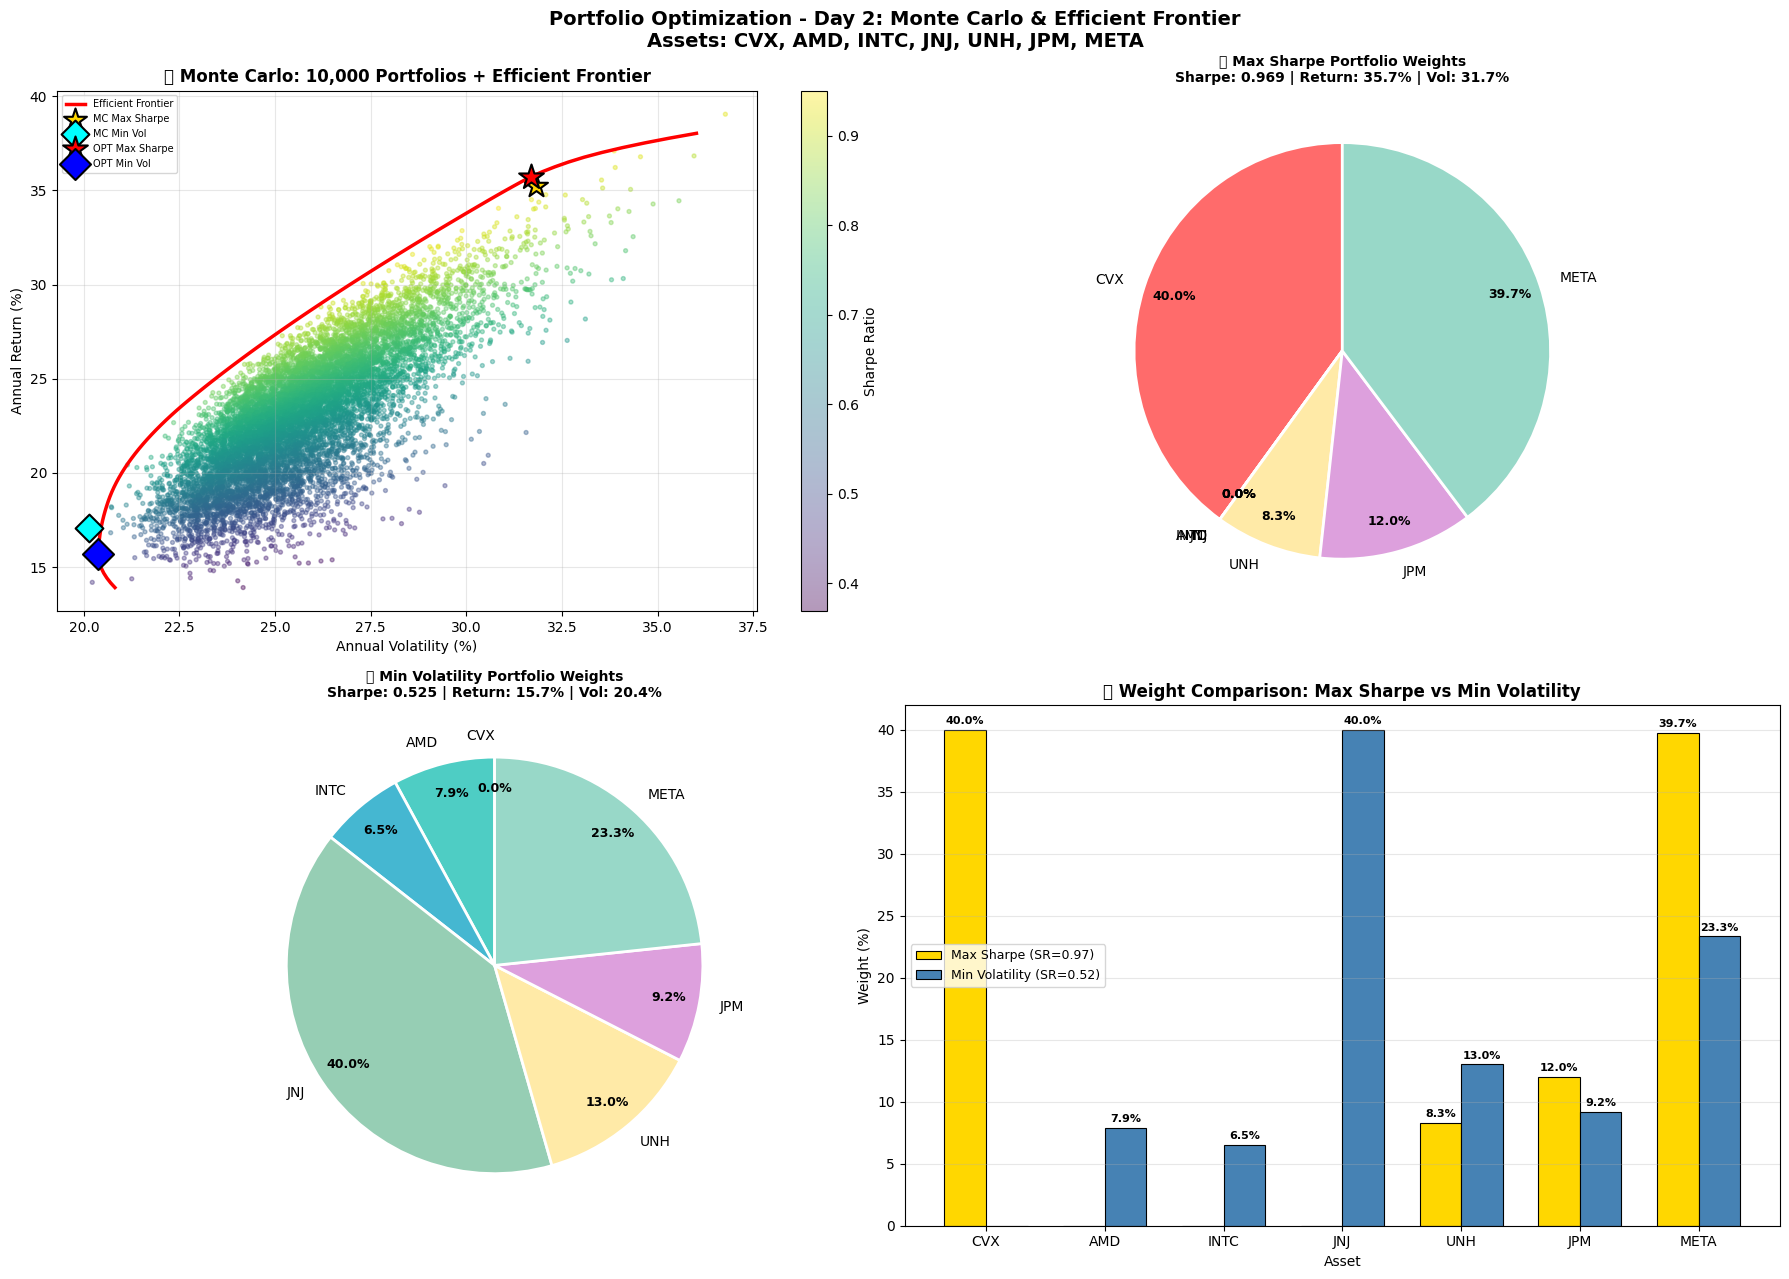

✅ Chart saved as 'portfolio_day2_analysis.png'

📋 DAY 2 COMPLETE - PORTFOLIO COMPARISON SUMMARY
     Portfolio  Return (%)  Volatility (%)  Sharpe Ratio
  Equal Weight      23.121          24.952         0.726
 MC Max Sharpe      35.248          31.815         0.951
    MC Min Vol      17.064          20.128         0.599
OPT Max Sharpe      35.728          31.701         0.969
   OPT Min Vol      15.695          20.378         0.525

🏆 BEST RISK-ADJUSTED PORTFOLIO: OPT MAX SHARPE
   📈 Return     : 35.73%
   📉 Volatility : 31.70%
   ⭐ Sharpe     : 0.969

🚀 Ready for Day 3: Backtesting & Performance Attribution!


In [1]:
# ============================================================
# PORTFOLIO OPTIMIZATION - DAY 2
# Monte Carlo Simulation & Efficient Frontier
# Assets: CVX, AMD, INTC, JNJ, UNH, JPM, META
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: RE-LOAD DATA (Run this even if Day 1 is loaded)
# ============================================================

tickers = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
risk_free_rate = 0.05

print("📥 Re-loading data for Day 2...")

data = yf.download(
    tickers,
    start='2019-01-01',
    end='2024-01-01',
    auto_adjust=True
)['Close']

returns = data.pct_change().dropna()
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print(f"✅ Data ready: {returns.shape[0]} trading days x {returns.shape[1]} assets")

# ============================================================
# STEP 2: MONTE CARLO SIMULATION (10,000 Random Portfolios)
# ============================================================

print("\n🎲 Running Monte Carlo Simulation (10,000 portfolios)...")

np.random.seed(42)
n_simulations = 10000
n_assets = len(tickers)

# Storage arrays
mc_returns     = np.zeros(n_simulations)
mc_volatility  = np.zeros(n_simulations)
mc_sharpe      = np.zeros(n_simulations)
mc_weights     = np.zeros((n_simulations, n_assets))

for i in range(n_simulations):
    # Generate random weights that sum to 1
    weights = np.random.random(n_assets)
    weights /= weights.sum()

    # Portfolio metrics
    port_return = np.dot(weights, annual_returns)
    port_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    port_volatility = np.sqrt(port_variance)
    port_sharpe = (port_return - risk_free_rate) / port_volatility

    # Store results
    mc_returns[i]    = port_return
    mc_volatility[i] = port_volatility
    mc_sharpe[i]     = port_sharpe
    mc_weights[i]    = weights

print(f"✅ Simulation complete: {n_simulations:,} portfolios generated")

# ============================================================
# STEP 3: IDENTIFY KEY PORTFOLIOS FROM SIMULATION
# ============================================================

print("\n🔍 Identifying Key Portfolios...")

# Maximum Sharpe Ratio Portfolio
max_sharpe_idx       = np.argmax(mc_sharpe)
max_sharpe_return    = mc_returns[max_sharpe_idx]
max_sharpe_vol       = mc_volatility[max_sharpe_idx]
max_sharpe_val       = mc_sharpe[max_sharpe_idx]
max_sharpe_weights   = mc_weights[max_sharpe_idx]

# Minimum Volatility Portfolio
min_vol_idx          = np.argmin(mc_volatility)
min_vol_return       = mc_returns[min_vol_idx]
min_vol_vol          = mc_volatility[min_vol_idx]
min_vol_sharpe       = mc_sharpe[min_vol_idx]
min_vol_weights      = mc_weights[min_vol_idx]

print("\n⭐ MAX SHARPE RATIO PORTFOLIO (Monte Carlo):")
print(f"   📈 Return     : {max_sharpe_return*100:.2f}%")
print(f"   📉 Volatility : {max_sharpe_vol*100:.2f}%")
print(f"   ⭐ Sharpe     : {max_sharpe_val:.3f}")
print("\n   Asset Weights:")
for ticker, weight in zip(tickers, max_sharpe_weights):
    print(f"   {ticker:5s}: {weight*100:.2f}%")

print("\n🛡️  MIN VOLATILITY PORTFOLIO (Monte Carlo):")
print(f"   📈 Return     : {min_vol_return*100:.2f}%")
print(f"   📉 Volatility : {min_vol_vol*100:.2f}%")
print(f"   ⭐ Sharpe     : {min_vol_sharpe:.3f}")
print("\n   Asset Weights:")
for ticker, weight in zip(tickers, min_vol_weights):
    print(f"   {ticker:5s}: {weight*100:.2f}%")

# ============================================================
# STEP 4: CONVEX OPTIMIZATION (Precise Efficient Frontier)
# ============================================================

print("\n🔧 Running Convex Optimization for Precise Portfolios...")

# --- Helper Functions ---
def portfolio_return(weights):
    return np.dot(weights, annual_returns)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def neg_sharpe(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    return -(ret - risk_free_rate) / vol

# Constraints: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

# Bounds: each weight between 0% and 40%
bounds = tuple((0.0, 0.40) for _ in range(n_assets))

# Initial guess: equal weights
init_weights = np.array([1/n_assets] * n_assets)

# --- Optimize for Max Sharpe ---
opt_sharpe = minimize(
    neg_sharpe,
    init_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_sharpe_weights = opt_sharpe.x
opt_sharpe_return  = portfolio_return(opt_sharpe_weights)
opt_sharpe_vol     = portfolio_volatility(opt_sharpe_weights)
opt_sharpe_ratio   = (opt_sharpe_return - risk_free_rate) / opt_sharpe_vol

# --- Optimize for Min Volatility ---
opt_minvol = minimize(
    portfolio_volatility,
    init_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_minvol_weights = opt_minvol.x
opt_minvol_return  = portfolio_return(opt_minvol_weights)
opt_minvol_vol     = portfolio_volatility(opt_minvol_weights)
opt_minvol_sharpe  = (opt_minvol_return - risk_free_rate) / opt_minvol_vol

print("\n✅ OPTIMIZED MAX SHARPE PORTFOLIO:")
print(f"   📈 Return     : {opt_sharpe_return*100:.2f}%")
print(f"   📉 Volatility : {opt_sharpe_vol*100:.2f}%")
print(f"   ⭐ Sharpe     : {opt_sharpe_ratio:.3f}")
print("\n   Asset Weights:")
for ticker, weight in zip(tickers, opt_sharpe_weights):
    bar = '█' * int(weight * 50)
    print(f"   {ticker:5s}: {weight*100:5.2f}%  {bar}")

print("\n✅ OPTIMIZED MIN VOLATILITY PORTFOLIO:")
print(f"   📈 Return     : {opt_minvol_return*100:.2f}%")
print(f"   📉 Volatility : {opt_minvol_vol*100:.2f}%")
print(f"   ⭐ Sharpe     : {opt_minvol_sharpe:.3f}")
print("\n   Asset Weights:")
for ticker, weight in zip(tickers, opt_minvol_weights):
    bar = '█' * int(weight * 50)
    print(f"   {ticker:5s}: {weight*100:5.2f}%  {bar}")

# ============================================================
# STEP 5: BUILD THE EFFICIENT FRONTIER CURVE
# ============================================================

print("\n📐 Building Efficient Frontier Curve...")

# Generate target returns across the range
target_returns = np.linspace(
    mc_returns.min(),
    mc_returns.max(),
    100
)

frontier_volatility = []
frontier_weights_list = []

for target in target_returns:
    constraints_ef = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x, t=target: portfolio_return(x) - t}
    ]
    result = minimize(
        portfolio_volatility,
        init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_ef
    )
    if result.success:
        frontier_volatility.append(result.fun)
        frontier_weights_list.append(result.x)
    else:
        frontier_volatility.append(np.nan)
        frontier_weights_list.append([np.nan]*n_assets)

frontier_volatility = np.array(frontier_volatility)
valid = ~np.isnan(frontier_volatility)

print(f"✅ Efficient Frontier built with {valid.sum()} valid points")

# ============================================================
# STEP 6: VISUALIZATIONS
# ============================================================

print("\n🎨 Generating Day 2 Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Portfolio Optimization - Day 2: Monte Carlo & Efficient Frontier\nAssets: CVX, AMD, INTC, JNJ, UNH, JPM, META',
             fontsize=14, fontweight='bold')

# -----------------------------------------------
# Plot 1: Monte Carlo Scatter (Colored by Sharpe)
# -----------------------------------------------
ax1 = axes[0, 0]
scatter = ax1.scatter(
    mc_volatility * 100,
    mc_returns * 100,
    c=mc_sharpe,
    cmap='viridis',
    alpha=0.4,
    s=8
)
plt.colorbar(scatter, ax=ax1, label='Sharpe Ratio')

# Efficient Frontier line
ax1.plot(
    frontier_volatility[valid] * 100,
    target_returns[valid] * 100,
    'r-', linewidth=2.5, label='Efficient Frontier', zorder=5
)

# Key portfolio points
ax1.scatter(max_sharpe_vol*100, max_sharpe_return*100,
            s=300, color='gold', marker='*', zorder=10,
            edgecolors='black', linewidth=1.5, label='MC Max Sharpe')
ax1.scatter(min_vol_vol*100, min_vol_return*100,
            s=200, color='cyan', marker='D', zorder=10,
            edgecolors='black', linewidth=1.5, label='MC Min Vol')
ax1.scatter(opt_sharpe_vol*100, opt_sharpe_return*100,
            s=350, color='red', marker='*', zorder=11,
            edgecolors='black', linewidth=1.5, label='OPT Max Sharpe')
ax1.scatter(opt_minvol_vol*100, opt_minvol_return*100,
            s=250, color='blue', marker='D', zorder=11,
            edgecolors='black', linewidth=1.5, label='OPT Min Vol')

ax1.set_title('🎲 Monte Carlo: 10,000 Portfolios + Efficient Frontier', fontweight='bold')
ax1.set_xlabel('Annual Volatility (%)')
ax1.set_ylabel('Annual Return (%)')
ax1.legend(fontsize=7, loc='upper left')
ax1.grid(True, alpha=0.3)

# -----------------------------------------------
# Plot 2: Optimal Weights - Max Sharpe
# -----------------------------------------------
ax2 = axes[0, 1]
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
wedges, texts, autotexts = ax2.pie(
    opt_sharpe_weights,
    labels=tickers,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax2.set_title(f'⭐ Max Sharpe Portfolio Weights\nSharpe: {opt_sharpe_ratio:.3f} | Return: {opt_sharpe_return*100:.1f}% | Vol: {opt_sharpe_vol*100:.1f}%',
              fontweight='bold', fontsize=10)

# -----------------------------------------------
# Plot 3: Optimal Weights - Min Volatility
# -----------------------------------------------
ax3 = axes[1, 0]
wedges2, texts2, autotexts2 = ax3.pie(
    opt_minvol_weights,
    labels=tickers,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts2:
    text.set_fontsize(9)
    text.set_fontweight('bold')
ax3.set_title(f'🛡️ Min Volatility Portfolio Weights\nSharpe: {opt_minvol_sharpe:.3f} | Return: {opt_minvol_return*100:.1f}% | Vol: {opt_minvol_vol*100:.1f}%',
              fontweight='bold', fontsize=10)

# -----------------------------------------------
# Plot 4: Side-by-Side Weight Comparison Bar Chart
# -----------------------------------------------
ax4 = axes[1, 1]
x = np.arange(n_assets)
width = 0.35

bars1 = ax4.bar(x - width/2, opt_sharpe_weights * 100, width,
                label=f'Max Sharpe (SR={opt_sharpe_ratio:.2f})',
                color='gold', edgecolor='black', linewidth=0.8)
bars2 = ax4.bar(x + width/2, opt_minvol_weights * 100, width,
                label=f'Min Volatility (SR={opt_minvol_sharpe:.2f})',
                color='steelblue', edgecolor='black', linewidth=0.8)

ax4.set_title('📊 Weight Comparison: Max Sharpe vs Min Volatility', fontweight='bold')
ax4.set_xlabel('Asset')
ax4.set_ylabel('Weight (%)')
ax4.set_xticks(x)
ax4.set_xticklabels(tickers)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    h = bar.get_height()
    if h > 1:
        ax4.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    if h > 1:
        ax4.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('portfolio_day2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'portfolio_day2_analysis.png'")

# ============================================================
# STEP 7: FINAL COMPARISON TABLE
# ============================================================

print("\n" + "="*65)
print("📋 DAY 2 COMPLETE - PORTFOLIO COMPARISON SUMMARY")
print("="*65)

equal_weights   = np.array([1/n_assets] * n_assets)
eq_return       = portfolio_return(equal_weights)
eq_vol          = portfolio_volatility(equal_weights)
eq_sharpe       = (eq_return - risk_free_rate) / eq_vol

summary = pd.DataFrame({
    'Portfolio': ['Equal Weight', 'MC Max Sharpe', 'MC Min Vol', 'OPT Max Sharpe', 'OPT Min Vol'],
    'Return (%)': [eq_return*100, max_sharpe_return*100, min_vol_return*100,
                   opt_sharpe_return*100, opt_minvol_return*100],
    'Volatility (%)': [eq_vol*100, max_sharpe_vol*100, min_vol_vol*100,
                       opt_sharpe_vol*100, opt_minvol_vol*100],
    'Sharpe Ratio': [eq_sharpe, max_sharpe_val, min_vol_sharpe,
                     opt_sharpe_ratio, opt_minvol_sharpe]
}).round(3)

print(summary.to_string(index=False))

print("\n" + "="*65)
print("🏆 BEST RISK-ADJUSTED PORTFOLIO: OPT MAX SHARPE")
print(f"   📈 Return     : {opt_sharpe_return*100:.2f}%")
print(f"   📉 Volatility : {opt_sharpe_vol*100:.2f}%")
print(f"   ⭐ Sharpe     : {opt_sharpe_ratio:.3f}")
print("="*65)
print("\n🚀 Ready for Day 3: Backtesting & Performance Attribution!")

[********************* 43%                       ]  3 of 7 completed

📥 Loading data with Train/Test Split...


[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  1 of 1 completed


✅ Train set: 756 days (2019-01-02 → 2021-12-31))
✅ Test set : 500 days (2022-01-03  → 2023-12-29))

🔧 Re-optimizing portfolio weights on training data...
✅ Weights optimized on training data

   Max Sharpe Weights:
   CVX  : 40.00%  ████████████████
   AMD  : 0.00%  
   INTC : 0.00%  
   JNJ  : 4.08%  █
   UNH  : 5.43%  ██
   JPM  : 25.39%  ██████████
   META : 25.11%  ██████████

📈 Running Backtest on Test Period (2022–2024)...
📥 Downloading S&P 500 benchmark...
✅ Backtest complete

📊 Calculating Performance Metrics...

📋 COMPREHENSIVE BACKTEST PERFORMANCE METRICS (2022–2024)
Portfolio       ⭐ Max Sharpe  🛡️ Min Volatility  ⚖️ Equal Weight  📊 SPY Benchmark
Total Return %        13.440              9.800           16.880            2.650
Ann Return %          11.970              6.560           10.380            3.220
Ann Vol %             33.550             19.220           22.470           19.530
Sharpe Ratio           0.208              0.081            0.240           -0.091
Sortin

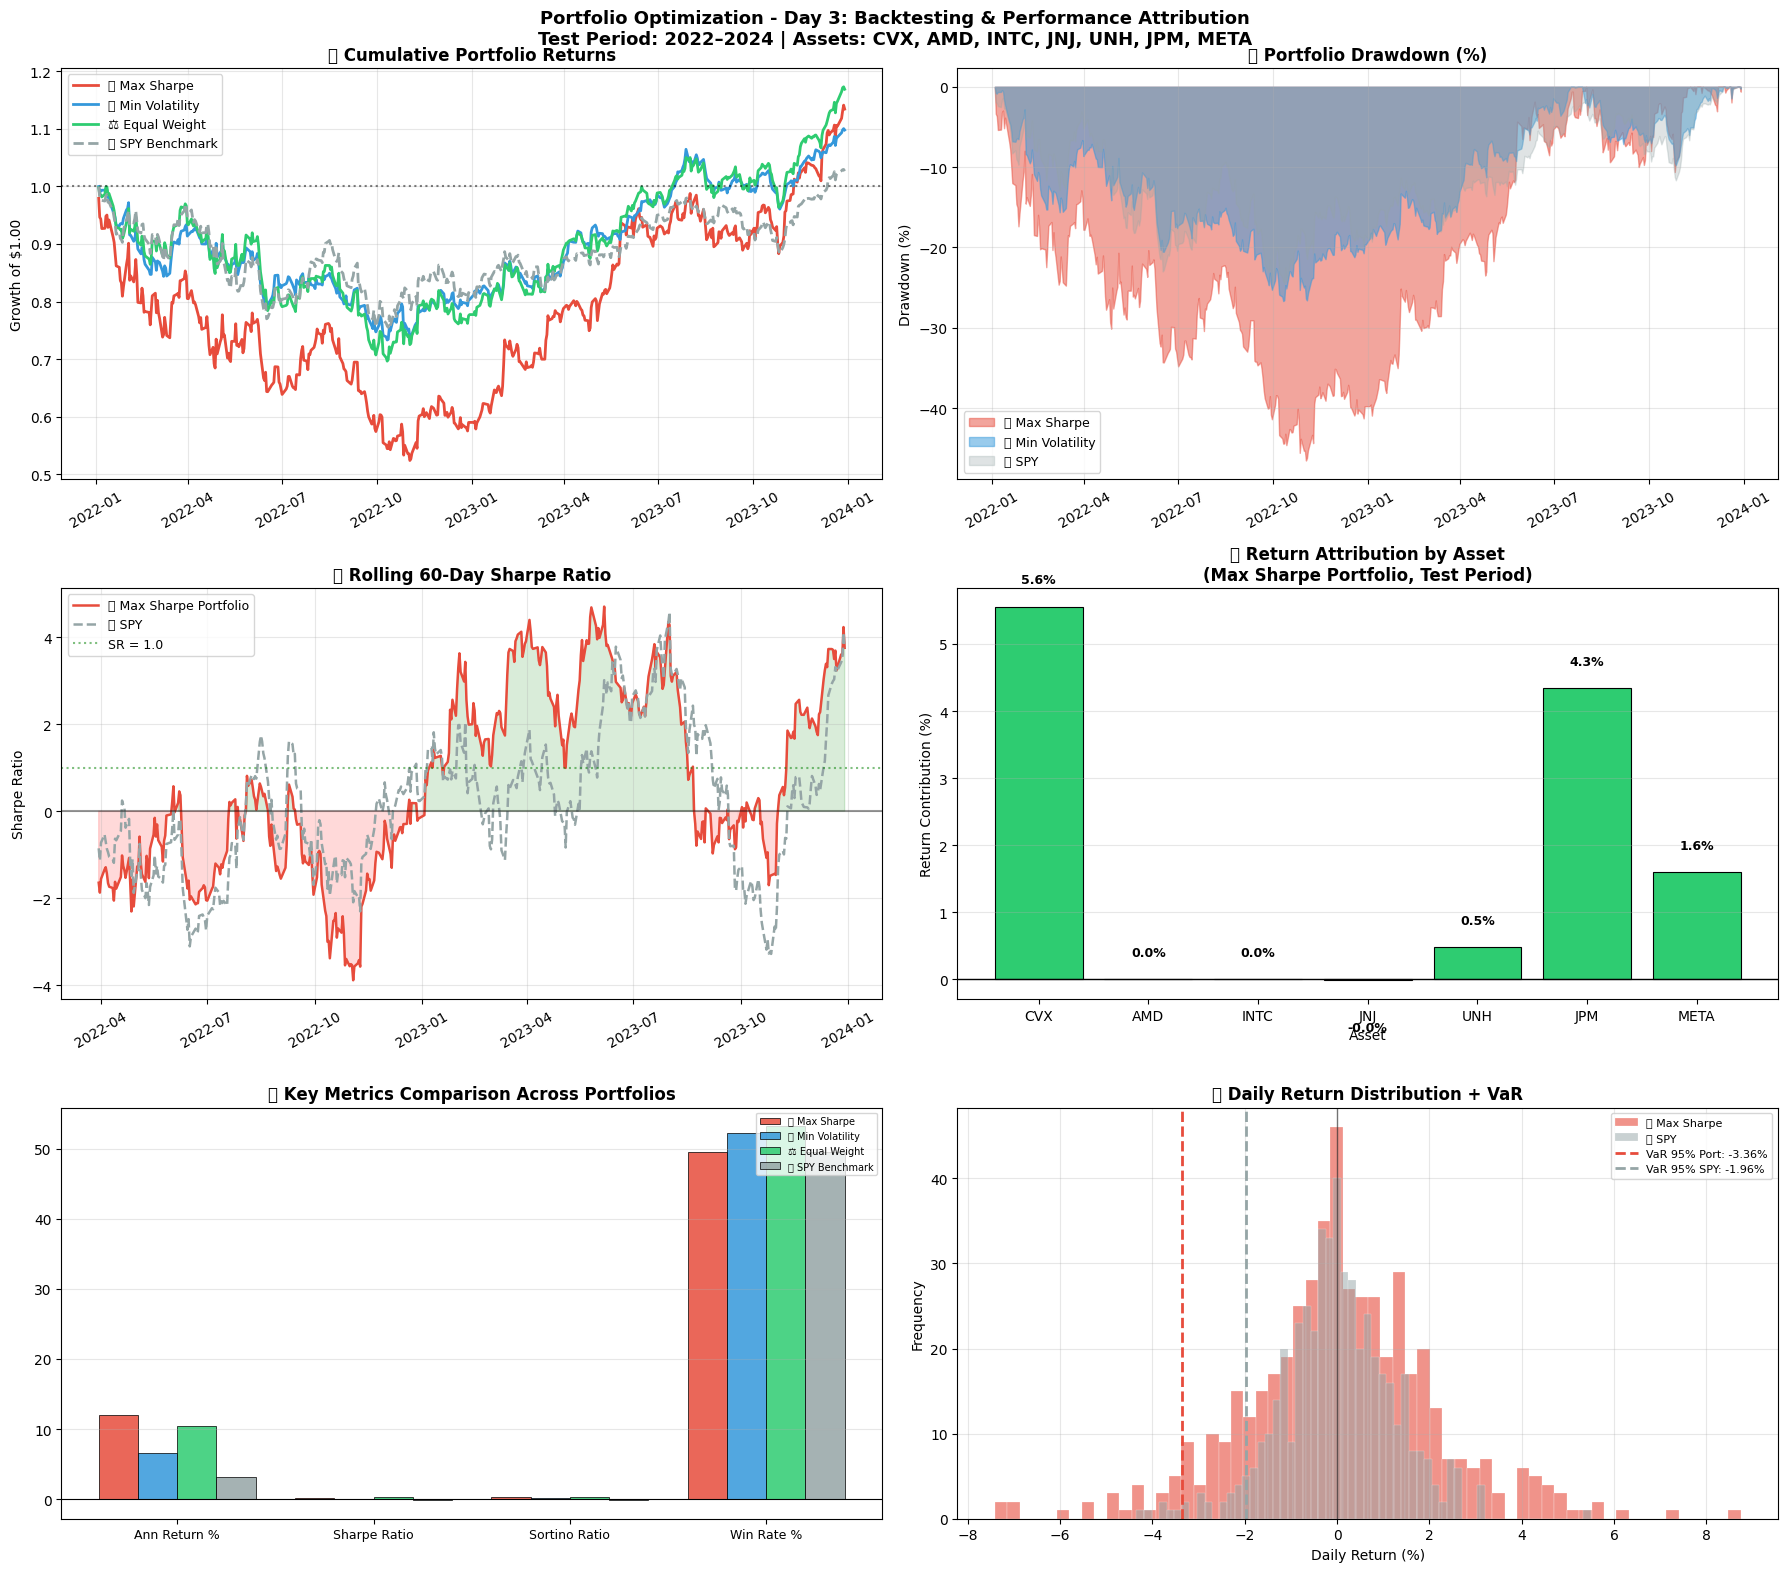

✅ Chart saved as 'portfolio_day3_backtest.png'

🏁 DAY 3 COMPLETE - FULL PERFORMANCE REPORT

📅 BACKTEST PERIOD     : Jan 2022 – Jan 2024
🏋️  TRAINING PERIOD    : Jan 2019 – Dec 2021
📦 ASSETS             : CVX, AMD, INTC, JNJ, UNH, JPM, META
📊 BENCHMARK          : SPY (S&P 500 ETF)

📈 MAX SHARPE PORTFOLIO:
   Total Return        : 13.44%
   Annual Return       : 11.97%
   Annual Volatility   : 33.55%
   Sharpe Ratio        : 0.208
   Sortino Ratio       : 0.305
   Max Drawdown        : -46.52%
   Win Rate            : 49.60%

📊 SPY BENCHMARK:
   Total Return        : 2.65%
   Annual Return       : 3.22%
   Annual Volatility   : 19.53%
   Sharpe Ratio        : -0.091
   Max Drawdown        : -24.47%

🏆 PORTFOLIO ALPHA vs SPY  : +8.75%

🚀 Ready for Day 4: Risk Management & Stress Testing!


In [5]:
# ============================================================
# PORTFOLIO OPTIMIZATION - DAY 3
# Backtesting & Performance Attribution
# Assets: CVX, AMD, INTC, JNJ, UNH, JPM, META
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from scipy.optimize import minimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: RE-LOAD DATA (Train + Test Split)
# ============================================================

tickers = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
risk_free_rate = 0.05

print("📥 Loading data with Train/Test Split...")

# FULL DATA
data = yf.download(
    tickers,
    start='2019-01-01',
    end='2024-01-01',
    auto_adjust=True
)['Close']

# TRAIN: 2019–2022 (optimize weights here)
# TEST:  2022–2024 (backtest on unseen data)
train_data = data.loc['2019-01-01':'2021-12-31']
test_data  = data.loc['2022-01-01':'2024-01-01']

train_returns = train_data.pct_change().dropna()
test_returns  = test_data.pct_change().dropna()

annual_returns_train = train_returns.mean() * 252
cov_matrix_train     = train_returns.cov() * 252

print(f"✅ Train set: {train_returns.shape[0]} days ({train_data.index[0].date()} → {train_data.index[-1].date()}))")
print(f"✅ Test set : {test_returns.shape[0]} days ({test_data.index[0].date()}  → {test_data.index[-1].date()}))")

# ============================================================
# STEP 2: RE-OPTIMIZE WEIGHTS ON TRAINING DATA
# ============================================================

print("\n🔧 Re-optimizing portfolio weights on training data...")

n_assets = len(tickers)
init_weights = np.array([1/n_assets] * n_assets)
bounds = tuple((0.0, 0.40) for _ in range(n_assets))
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

def portfolio_return(weights, ann_ret=annual_returns_train):
    return np.dot(weights, ann_ret)

def portfolio_volatility(weights, cov=cov_matrix_train):
    return np.sqrt(np.dot(weights.T, np.dot(cov, weights)))

def neg_sharpe(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    return -(ret - risk_free_rate) / vol

# Max Sharpe
opt_sharpe = minimize(neg_sharpe, init_weights, method='SLSQP',
                      bounds=bounds, constraints=constraints)
sharpe_weights = opt_sharpe.x

# Min Volatility
opt_minvol = minimize(portfolio_volatility, init_weights, method='SLSQP',
                      bounds=bounds, constraints=constraints)
minvol_weights = opt_minvol.x

# Equal Weights
equal_weights = np.array([1/n_assets] * n_assets)

print("✅ Weights optimized on training data")
print("\n   Max Sharpe Weights:")
for t, w in zip(tickers, sharpe_weights):
    print(f"   {t:5s}: {w*100:.2f}%  {'█' * int(w*40)}")

# ============================================================
# STEP 3: COMPUTE CUMULATIVE RETURNS (BACKTEST)
# ============================================================

print("\n📈 Running Backtest on Test Period (2022–2024)...")

def cumulative_returns(weights, returns_df):
    """Compute portfolio cumulative return series"""
    port_daily = returns_df.dot(weights)
    cum_ret    = (1 + port_daily).cumprod()
    return port_daily, cum_ret

# Portfolio daily & cumulative returns
sharpe_daily, sharpe_cum   = cumulative_returns(sharpe_weights, test_returns)
minvol_daily, minvol_cum   = cumulative_returns(minvol_weights, test_returns)
equal_daily,  equal_cum    = cumulative_returns(equal_weights,  test_returns)

# S&P 500 Benchmark
print("📥 Downloading S&P 500 benchmark...")
spy = yf.download('SPY', start='2022-01-01', end='2024-01-01', auto_adjust=True)['Close']
spy_returns = spy.pct_change().dropna()
spy_cum     = (1 + spy_returns).cumprod()

print("✅ Backtest complete")

# ============================================================
# STEP 4: PERFORMANCE METRICS FUNCTION
# ============================================================

def performance_metrics(daily_returns, label, rf=risk_free_rate):
    """Calculate comprehensive performance metrics"""
    ann_return   = daily_returns.mean() * 252
    ann_vol      = daily_returns.std() * np.sqrt(252)
    sharpe       = (ann_return - rf) / ann_vol

    # Max Drawdown
    cum          = (1 + daily_returns).cumprod()
    rolling_max  = cum.cummax()
    drawdown     = (cum - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Sortino Ratio (downside deviation)
    downside     = daily_returns[daily_returns < 0]
    down_std     = downside.std() * np.sqrt(252)
    # Ensure down_std is a scalar before comparison
    if isinstance(down_std, pd.Series):
        down_std = down_std.iloc[0] if not down_std.empty else 0.0 # Handle empty series case
    sortino      = (ann_return - rf) / down_std if down_std != 0 else np.nan

    # Calmar Ratio
    calmar       = ann_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    # Win Rate
    win_rate     = (daily_returns > 0).sum() / len(daily_returns)

    # VaR & CVaR (95%)
    var_95       = np.percentile(daily_returns, 5)
    cvar_95      = daily_returns[daily_returns <= var_95].mean()

    # Total Return
    total_return = (1 + daily_returns).prod() - 1

    return {
        'Portfolio'     : label,
        'Total Return %': round(total_return * 100, 2),
        'Ann Return %'  : round(ann_return * 100, 2),
        'Ann Vol %'     : round(ann_vol * 100, 2),
        'Sharpe Ratio'  : round(sharpe, 3),
        'Sortino Ratio' : round(sortino, 3),
        'Calmar Ratio'  : round(calmar, 3),
        'Max Drawdown %': round(max_drawdown * 100, 2),
        'Win Rate %'    : round(win_rate * 100, 2),
        'VaR 95% (day)' : round(var_95 * 100, 3),
        'CVaR 95% (day)': round(cvar_95 * 100, 3),
    }

# ============================================================
# STEP 5: CALCULATE ALL METRICS
# ============================================================

print("\n📊 Calculating Performance Metrics...")

# Align SPY returns with portfolio dates
spy_aligned = spy_returns.reindex(sharpe_daily.index).fillna(0)

metrics_list = [
    performance_metrics(sharpe_daily, '⭐ Max Sharpe'),
    performance_metrics(minvol_daily, '🛡️ Min Volatility'),
    performance_metrics(equal_daily,  '⚖️ Equal Weight'),
    performance_metrics(spy_aligned.squeeze(),  '📊 SPY Benchmark'), # Use .squeeze() to convert single-column DataFrame to Series
]

metrics_df = pd.DataFrame(metrics_list)
metrics_df.set_index('Portfolio', inplace=True)

print("\n" + "="*75)
print("📋 COMPREHENSIVE BACKTEST PERFORMANCE METRICS (2022–2024)")
print("="*75)
print(metrics_df.T.to_string())
print("="*75)

# ============================================================
# STEP 6: PERFORMANCE ATTRIBUTION (BRINSON MODEL)
# ============================================================

print("\n🔬 Running Performance Attribution Analysis...")

# Calculate individual asset contributions to portfolio return
test_ann_returns = test_returns.mean() * 252

sharpe_contribution = pd.Series(
    sharpe_weights * test_ann_returns.values,
    index=tickers
)
minvol_contribution = pd.Series(
    minvol_weights * test_ann_returns.values,
    index=tickers
)
equal_contribution = pd.Series(
    equal_weights * test_ann_returns.values,
    index=tickers
)

print("\n📊 Return Contribution by Asset (Max Sharpe Portfolio:")
for ticker, contrib in sharpe_contribution.sort_values(ascending=False).items():
    bar = '█' * int(abs(contrib) * 100)
    sign = '+' if contrib >= 0 else '-'
    print(f"   {ticker:5s}: {sign}{abs(contrib)*100:.2f}%  {bar}")

# ============================================================
# STEP 7: ROLLING METRICS
# ============================================================

print("\n📉 Computing Rolling Performance Metrics (60-day window)...")

window = 60

rolling_sharpe_port = (
    sharpe_daily.rolling(window).mean() * 252 - risk_free_rate
) / (sharpe_daily.rolling(window).std() * np.sqrt(252))

rolling_sharpe_spy = (
    spy_aligned.rolling(window).mean().squeeze() * 252 - risk_free_rate # Squeeze here too
) / (spy_aligned.rolling(window).std().squeeze() * np.sqrt(252)) # Squeeze here too

# Rolling Drawdown
def rolling_drawdown(daily_ret):
    cum = (1 + daily_ret).cumprod()
    roll_max = cum.cummax()
    return (cum - roll_max) / roll_max

sharpe_dd = rolling_drawdown(sharpe_daily)
minvol_dd = rolling_drawdown(minvol_daily)
spy_dd    = rolling_drawdown(spy_aligned.squeeze()) # Squeeze here too

print("✅ Rolling metrics computed")

# ============================================================
# STEP 8: VISUALIZATIONS (2x3 Grid)
# ============================================================

print("\n🎨 Generating Day 3 Visualizations...")

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle(
    'Portfolio Optimization - Day 3: Backtesting & Performance Attribution\n'
    'Test Period: 2022–2024 | Assets: CVX, AMD, INTC, JNJ, UNH, JPM, META',
    fontsize=13, fontweight='bold'
)

colors = {
    '⭐ Max Sharpe'  : '#E74C3C',
    '🛡️ Min Vol'    : '#3498DB',
    '⚖️ Equal Weight': '#2ECC71',
    '📊 SPY'         : '#95A5A6'
}

# -----------------------------------------------
# Plot 1: Cumulative Returns
# -----------------------------------------------
ax1 = axes[0, 0]
ax1.plot(sharpe_cum.index, sharpe_cum.values,
         color='#E74C3C', linewidth=2.0, label='⭐ Max Sharpe')
ax1.plot(minvol_cum.index, minvol_cum.values,
         color='#3498DB', linewidth=2.0, label='🛡️ Min Volatility')
ax1.plot(equal_cum.index, equal_cum.values,
         color='#2ECC71', linewidth=2.0, label='⚖️ Equal Weight')
ax1.plot(spy_cum.index, spy_cum.values,
         color='#95A5A6', linewidth=2.0, linestyle='--', label='📊 SPY Benchmark')
ax1.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
ax1.set_title('📈 Cumulative Portfolio Returns', fontweight='bold')
ax1.set_ylabel('Growth of $1.00')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

# -----------------------------------------------
# Plot 2: Drawdown
# -----------------------------------------------
ax2 = axes[0, 1]
ax2.fill_between(sharpe_dd.index, sharpe_dd.values * 100,
                 alpha=0.5, color='#E74C3C', label='⭐ Max Sharpe')
ax2.fill_between(minvol_dd.index, minvol_dd.values * 100,
                 alpha=0.5, color='#3498DB', label='🛡️ Min Volatility')
ax2.fill_between(spy_dd.index, spy_dd.values * 100,
                 alpha=0.3, color='#95A5A6', label='📊 SPY')
ax2.set_title('📉 Portfolio Drawdown (%)', fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

# -----------------------------------------------
# Plot 3: Rolling Sharpe Ratio
# -----------------------------------------------
ax3 = axes[1, 0]
ax3.plot(rolling_sharpe_port.index, rolling_sharpe_port.values,
         color='#E74C3C', linewidth=1.8, label='⭐ Max Sharpe Portfolio')
ax3.plot(rolling_sharpe_spy.index, rolling_sharpe_spy.values,
         color='#95A5A6', linewidth=1.8, linestyle='--', label='📊 SPY')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.4)
ax3.axhline(y=1, color='green', linestyle=':', alpha=0.5, label='SR = 1.0')
ax3.fill_between(rolling_sharpe_port.index, rolling_sharpe_port.values, 0,
                 where=(rolling_sharpe_port.values > 0),
                 alpha=0.15, color='green')
ax3.fill_between(rolling_sharpe_port.index, rolling_sharpe_port.values, 0,
                 where=(rolling_sharpe_port.values < 0),
                 alpha=0.15, color='red')
ax3.set_title(f'📊 Rolling {window}-Day Sharpe Ratio', fontweight='bold')
ax3.set_ylabel('Sharpe Ratio')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30)

# -----------------------------------------------
# Plot 4: Performance Attribution Bar Chart
# -----------------------------------------------
ax4 = axes[1, 1]
contrib_colors = ['#E74C3C' if x < 0 else '#2ECC71'
                  for x in sharpe_contribution.values]
bars = ax4.bar(tickers, sharpe_contribution.values * 100,
               color=contrib_colors, edgecolor='black', linewidth=0.8)
ax4.axhline(y=0, color='black', linewidth=1.0)
ax4.set_title('🔬 Return Attribution by Asset\n(Max Sharpe Portfolio, Test Period)',
              fontweight='bold')
ax4.set_ylabel('Return Contribution (%)')
ax4.set_xlabel('Asset')
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, sharpe_contribution.values * 100):
    ypos = val + 0.3 if val >= 0 else val - 0.8
    ax4.text(bar.get_x() + bar.get_width()/2., ypos,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# -----------------------------------------------
# Plot 5: Metrics Radar / Bar Comparison
# -----------------------------------------------
ax5 = axes[2, 0]
metric_names = ['Ann Return %', 'Sharpe Ratio', 'Sortino Ratio', 'Win Rate %']
portfolios   = ['⭐ Max Sharpe', '🛡️ Min Volatility', '⚖️ Equal Weight', '📊 SPY Benchmark']
bar_colors   = ['#E74C3C', '#3498DB', '#2ECC71', '#95A5A6']

x = np.arange(len(metric_names))
width = 0.2

for i, (port, color) in enumerate(zip(portfolios, bar_colors)):
    values = [metrics_df.loc[port, m] for m in metric_names]
    ax5.bar(x + i*width, values, width, label=port,
            color=color, edgecolor='black', linewidth=0.6, alpha=0.85)

ax5.set_title('📊 Key Metrics Comparison Across Portfolios', fontweight='bold')
ax5.set_xticks(x + width*1.5)
ax5.set_xticklabels(metric_names, fontsize=9)
ax5.legend(fontsize=7, loc='upper right')
ax5.grid(True, alpha=0.3, axis='y')
ax5.axhline(y=0, color='black', linewidth=0.8)

# -----------------------------------------------
# Plot 6: Daily Return Distribution
# -----------------------------------------------
ax6 = axes[2, 1]
ax6.hist(sharpe_daily.values * 100, bins=60, alpha=0.6,
         color='#E74C3C', label='⭐ Max Sharpe', edgecolor='white', linewidth=0.3)
ax6.hist(spy_aligned.values * 100, bins=60, alpha=0.5,
         color='#95A5A6', label='📊 SPY', edgecolor='white', linewidth=0.3)

# VaR lines
var_port = np.percentile(sharpe_daily.values * 100, 5)
var_spy  = np.percentile(spy_aligned.values * 100, 5)
ax6.axvline(x=var_port, color='#E74C3C', linestyle='--', linewidth=2,
            label=f'VaR 95% Port: {var_port:.2f}%')
ax6.axvline(x=var_spy, color='#95A5A6', linestyle='--', linewidth=2,
            label=f'VaR 95% SPY: {var_spy:.2f}%')
ax6.axvline(x=0, color='black', linewidth=1.0, alpha=0.5)

ax6.set_title('📊 Daily Return Distribution + VaR', fontweight='bold')
ax6.set_xlabel('Daily Return (%)')
ax6.set_ylabel('Frequency')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_day3_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'portfolio_day3_backtest.png'")

# ============================================================
# STEP 9: FINAL SUMMARY REPORT
# ============================================================

print("\n" + "="*65)
print("🏁 DAY 3 COMPLETE - FULL PERFORMANCE REPORT")
print("="*65)

print(f"""
📅 BACKTEST PERIOD     : Jan 2022 – Jan 2024
🏋️  TRAINING PERIOD    : Jan 2019 – Dec 2021
📦 ASSETS             : {', '.join(tickers)}
📊 BENCHMARK          : SPY (S&P 500 ETF)

📈 MAX SHARPE PORTFOLIO:
   Total Return        : {metrics_df.loc['⭐ Max Sharpe', 'Total Return %']:.2f}%
   Annual Return       : {metrics_df.loc['⭐ Max Sharpe', 'Ann Return %']:.2f}%
   Annual Volatility   : {metrics_df.loc['⭐ Max Sharpe', 'Ann Vol %']:.2f}%
   Sharpe Ratio        : {metrics_df.loc['⭐ Max Sharpe', 'Sharpe Ratio']:.3f}
   Sortino Ratio       : {metrics_df.loc['⭐ Max Sharpe', 'Sortino Ratio']:.3f}
   Max Drawdown        : {metrics_df.loc['⭐ Max Sharpe', 'Max Drawdown %']:.2f}%
   Win Rate            : {metrics_df.loc['⭐ Max Sharpe', 'Win Rate %']:.2f}%

📊 SPY BENCHMARK:
   Total Return        : {metrics_df.loc['📊 SPY Benchmark', 'Total Return %']:.2f}%
   Annual Return       : {metrics_df.loc['📊 SPY Benchmark', 'Ann Return %']:.2f}%
   Annual Volatility   : {metrics_df.loc['📊 SPY Benchmark', 'Ann Vol %']:.2f}%
   Sharpe Ratio        : {metrics_df.loc['📊 SPY Benchmark', 'Sharpe Ratio']:.3f}
   Max Drawdown        : {metrics_df.loc['📊 SPY Benchmark', 'Max Drawdown %']:.2f}%
""")

# Alpha vs Benchmark
alpha = (metrics_df.loc['⭐ Max Sharpe', 'Ann Return %'] -
         metrics_df.loc['📊 SPY Benchmark', 'Ann Return %'])
print(f"🏆 PORTFOLIO ALPHA vs SPY  : {alpha:+.2f}%")
print("="*65)
print("\n🚀 Ready for Day 4: Risk Management & Stress Testing!")

🛡️  DAY 4: RISK MANAGEMENT & STRESS TESTING

📥 Loading portfolio data...


[*********************100%***********************]  8 of 8 completed


✅ Data loaded: 2018-01-03 → 2023-12-29
   Total trading days: 1508

⚙️  Re-computing optimal weights...
✅ Weights loaded:
   CVX  : Max Sharpe=0.0%  Min Vol=0.0%  Equal=14.3%
   AMD  : Max Sharpe=72.4%  Min Vol=0.1%  Equal=14.3%
   INTC : Max Sharpe=0.0%  Min Vol=1.4%  Equal=14.3%
   JNJ  : Max Sharpe=0.0%  Min Vol=71.2%  Equal=14.3%
   UNH  : Max Sharpe=27.6%  Min Vol=4.7%  Equal=14.3%
   JPM  : Max Sharpe=0.0%  Min Vol=9.6%  Equal=14.3%
   META : Max Sharpe=0.0%  Min Vol=13.1%  Equal=14.3%

🔥 SECTION 3: HISTORICAL STRESS TESTS

Scenario                       Portfolio             Return    Max DD    Sharpe
--------------------------------------------------------------------------------
🦠 COVID Crash (Feb–Mar 2020)   📊 SPY                 -30.3%    -33.7%       N/A
                               ⭐ Max Sharpe          -15.9%    -32.3%   -0.870
                               🛡️ Min Vol            -26.4%    -29.1%   -1.606
                               ⚖️ Equal Wt           -28.9%    -3

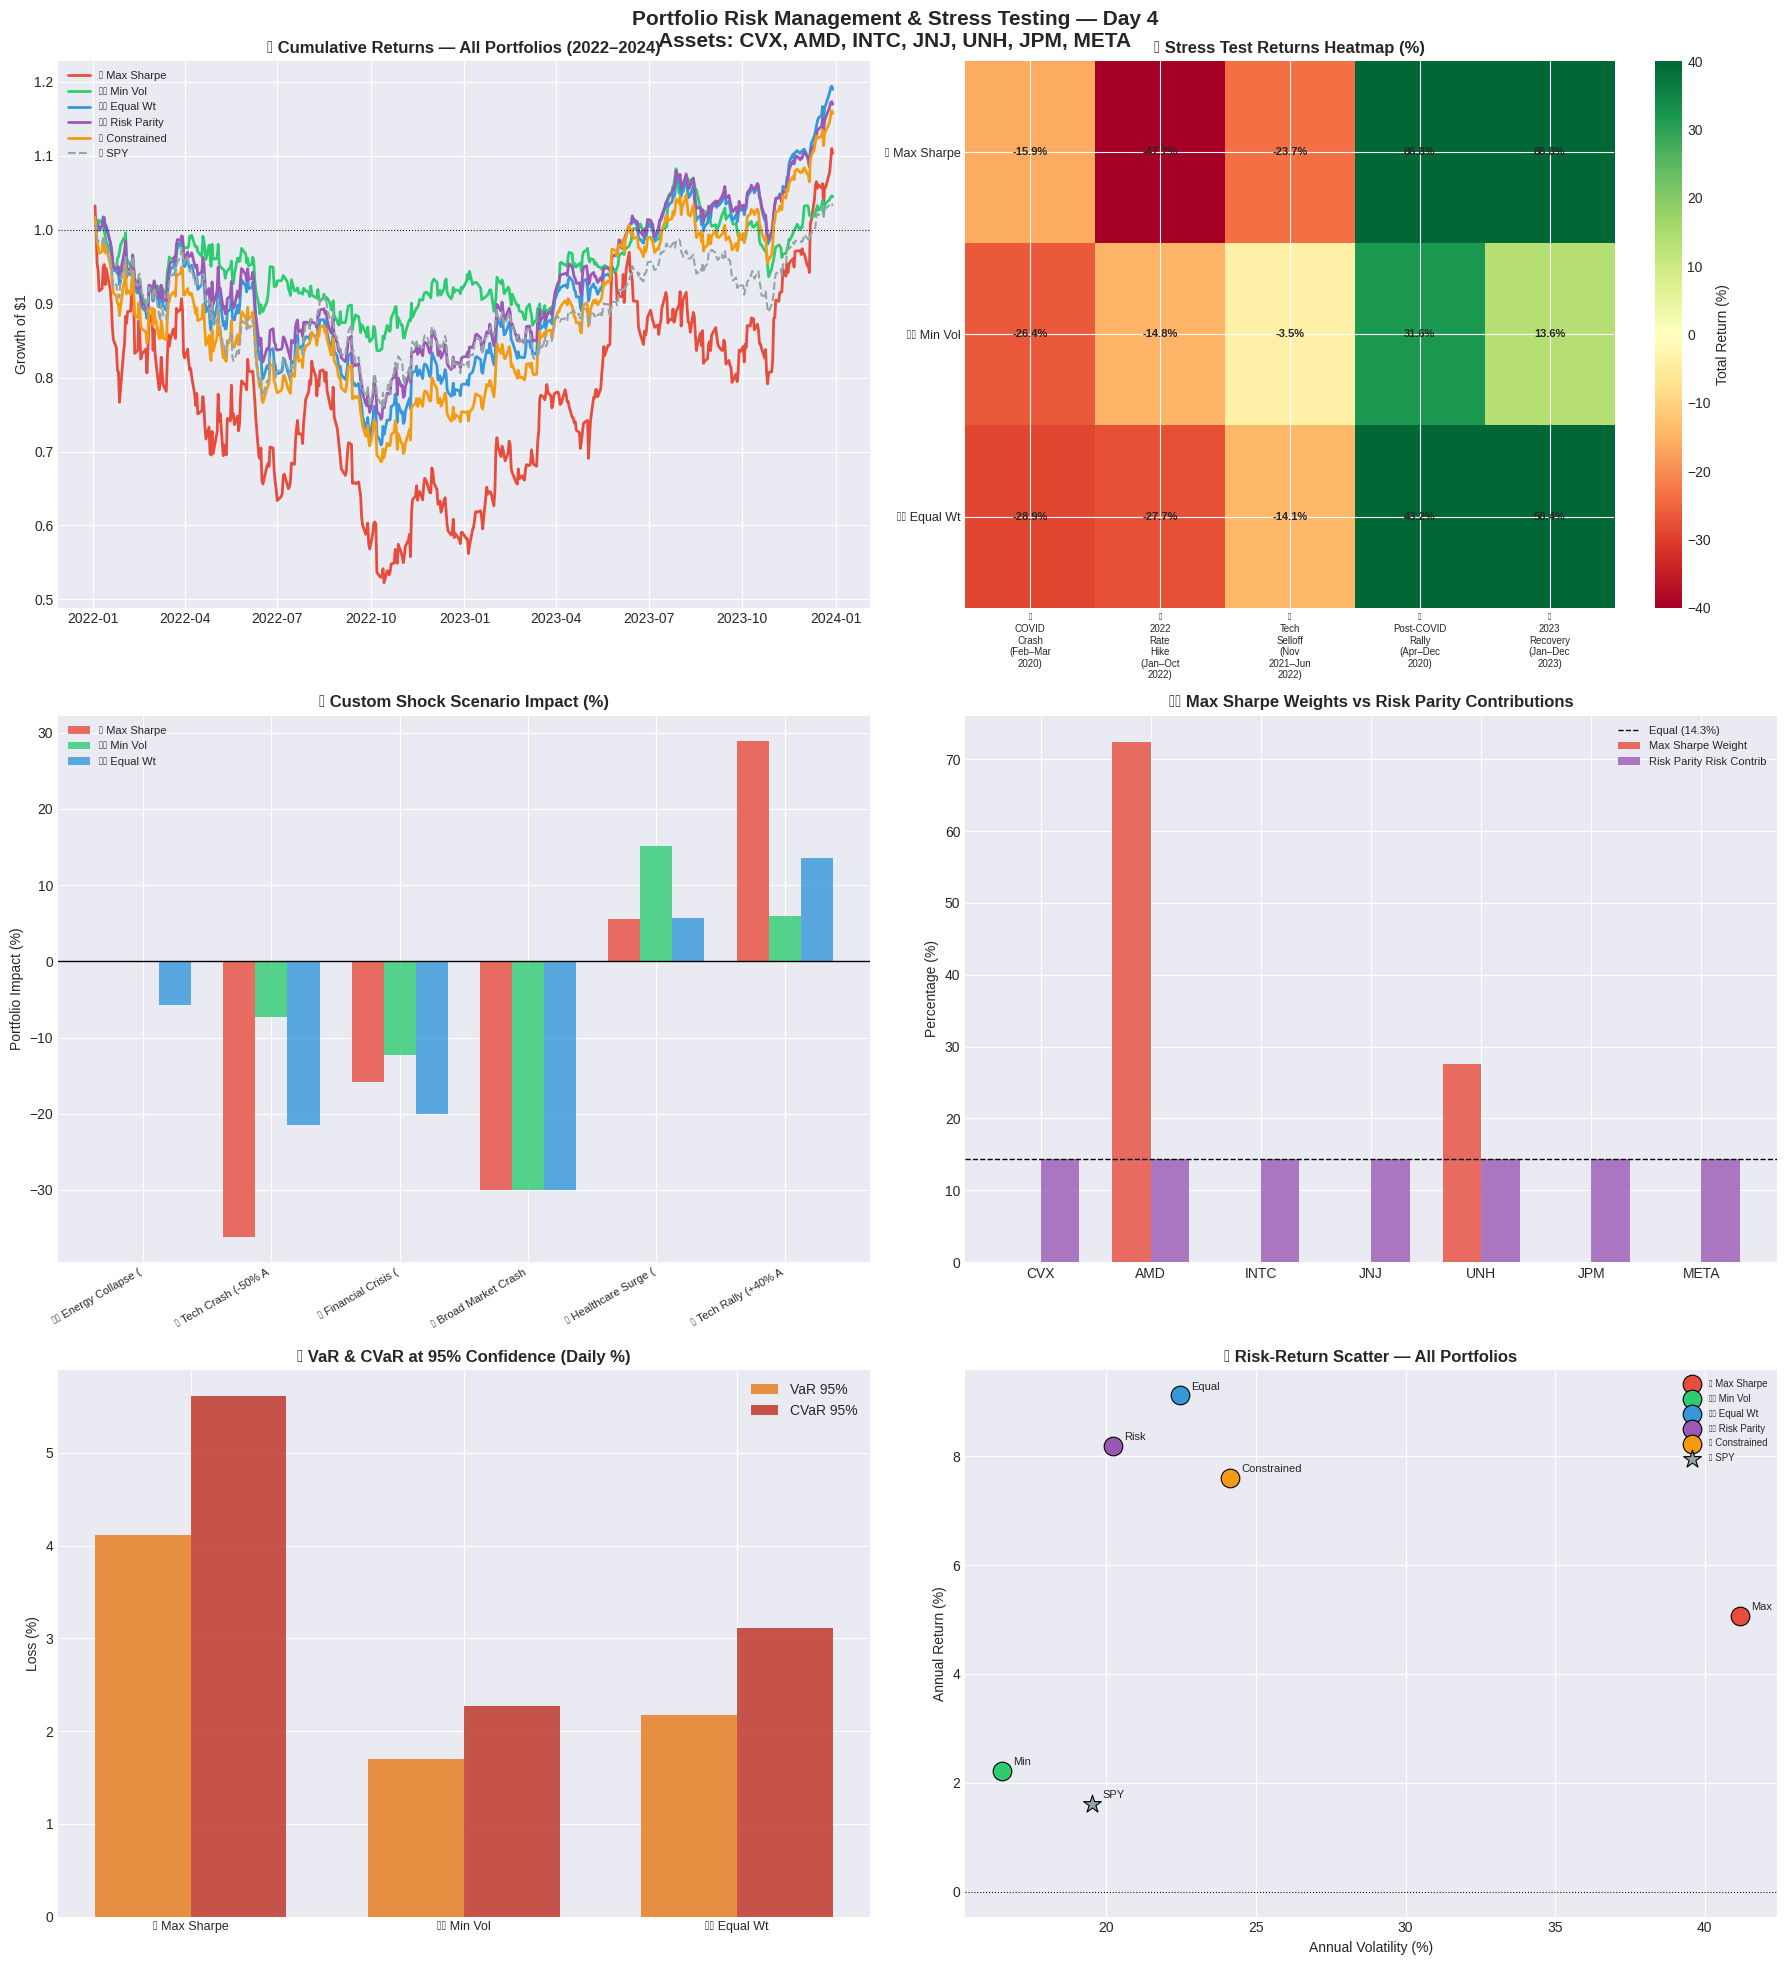

✅ Chart saved as 'portfolio_day4_risk.png'

📋 DAY 4 COMPLETE — RISK MANAGEMENT REPORT

📅 BACKTEST PERIOD    : Jan 2022 → Jan 2024
🏋️  ASSETS            : CVX, AMD, INTC, JNJ, UNH, JPM, META
📊 BENCHMARK          : SPY (S&P 500 ETF)

🔥 STRESS TEST SUMMARY:
   Worst scenario for Max Sharpe: 2022 Rate Hike
   Best  scenario for Max Sharpe: 2023 Recovery

📉 SHOCK ANALYSIS:
   Most vulnerable shock: Energy Collapse (-40% CVX)
   Most resilient shock:  Tech Rally (positive impact)

📊 VAR ANALYSIS (95% confidence, daily):
   Max Sharpe VaR:   -4.111%
   Min Vol VaR:      -1.694%
   Equal Weight VaR: -2.175%

⚖️  RISK PARITY PORTFOLIO:
   Ann Return:   22.24%
   Ann Vol:      23.84%
   Sharpe Ratio: 0.723

🔒 CONSTRAINED PORTFOLIO (5%-25% limits):
   Ann Return:   34.02%
   Ann Vol:      26.65%
   Sharpe Ratio: 1.089

🏆 BEST RISK-ADJUSTED (Test Period): ⚖️ Equal Wt
   Sharpe: 0.183

🛡️  SAFEST PORTFOLIO (Min Drawdown):  ⭐ Max Sharpe
   Max DD: -49.36%


🚀 Ready for Day 5: Dynamic Rebalancing & F

In [6]:
# ============================================================
# DAY 4: RISK MANAGEMENT & STRESS TESTING
# Portfolio Optimization Project — Phase 2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
import warnings
from scipy.optimize import minimize
from scipy import stats
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("=" * 65)
print("🛡️  DAY 4: RISK MANAGEMENT & STRESS TESTING")
print("=" * 65)

# ============================================================
# SECTION 1: RELOAD DATA
# ============================================================
print("\n📥 Loading portfolio data...")

ASSETS = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
BENCHMARK = 'SPY'
FULL_START = '2018-01-01'
FULL_END   = '2024-01-01'

# Download full data
raw = yf.download(
    ASSETS + [BENCHMARK],
    start=FULL_START,
    end=FULL_END,
    auto_adjust=True,
    progress=True
)['Close']

prices    = raw[ASSETS].dropna()
spy_price = raw[BENCHMARK].dropna()

returns   = prices.pct_change().dropna()
spy_ret   = spy_price.pct_change().dropna()

# Align
returns, spy_ret = returns.align(spy_ret, join='inner', axis=0)

print(f"✅ Data loaded: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"   Total trading days: {len(returns)}")

# ============================================================
# SECTION 2: RELOAD OPTIMAL WEIGHTS FROM DAY 3
# ============================================================
print("\n⚙️  Re-computing optimal weights...")

TRAIN_END = '2021-12-31'
train_ret = returns[returns.index <= TRAIN_END]

mean_ret = train_ret.mean()
cov_mat  = train_ret.cov()
n        = len(ASSETS)
rf_daily = 0.05 / 252  # 5% annual risk-free rate

def portfolio_performance(weights, mean_ret, cov_mat):
    ret = np.dot(weights, mean_ret) * 252
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat * 252, weights)))
    sharpe = (ret - 0.05) / vol
    return ret, vol, sharpe

def neg_sharpe(weights, mean_ret, cov_mat):
    return -portfolio_performance(weights, mean_ret, cov_mat)[2]

constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = tuple((0, 1) for _ in range(n))
w0 = np.array([1/n] * n)

# Max Sharpe
res_sharpe = minimize(neg_sharpe, w0, args=(mean_ret, cov_mat),
                      method='SLSQP', bounds=bounds, constraints=constraints)
w_sharpe = res_sharpe.x

# Min Volatility
res_minvol = minimize(
    lambda w: portfolio_performance(w, mean_ret, cov_mat)[1],
    w0, method='SLSQP', bounds=bounds, constraints=constraints
)
w_minvol = res_minvol.x

# Equal Weight
w_equal = np.array([1/n] * n)

print("✅ Weights loaded:")
for i, a in enumerate(ASSETS):
    print(f"   {a:5s}: Max Sharpe={w_sharpe[i]*100:.1f}%  "
          f"Min Vol={w_minvol[i]*100:.1f}%  "
          f"Equal={w_equal[i]*100:.1f}%")

# ============================================================
# SECTION 3: HISTORICAL STRESS TEST SCENARIOS
# ============================================================
print("\n" + "=" * 65)
print("🔥 SECTION 3: HISTORICAL STRESS TESTS")
print("=" * 65)

stress_periods = {
    '🦠 COVID Crash\n(Feb–Mar 2020)':     ('2020-02-01', '2020-03-23'),
    '📈 2022 Rate Hike\n(Jan–Oct 2022)':  ('2022-01-01', '2022-10-14'),
    '💥 Tech Selloff\n(Nov 2021–Jun 2022)':('2021-11-01', '2022-06-30'),
    '🔄 Post-COVID Rally\n(Apr–Dec 2020)': ('2020-04-01', '2020-12-31'),
    '🚀 2023 Recovery\n(Jan–Dec 2023)':    ('2023-01-01', '2023-12-31'),
}

portfolios = {
    '⭐ Max Sharpe': w_sharpe,
    '🛡️ Min Vol':   w_minvol,
    '⚖️ Equal Wt':  w_equal,
}

stress_results = {}

print(f"\n{'Scenario':<30} {'Portfolio':<18} {'Return':>9} {'Max DD':>9} {'Sharpe':>9}")
print("-" * 80)

for scenario, (start, end) in stress_periods.items():
    scenario_clean = scenario.replace('\n', ' ')
    stress_results[scenario_clean] = {}

    period_ret = returns[(returns.index >= start) & (returns.index <= end)]
    period_spy = spy_ret[(spy_ret.index >= start) & (spy_ret.index <= end)]

    if len(period_ret) < 5:
        continue

    for pname, weights in portfolios.items():
        port_ret = (period_ret * weights).sum(axis=1)
        cum_ret  = (1 + port_ret).cumprod()
        total_ret = cum_ret.iloc[-1] - 1
        roll_max  = cum_ret.cummax()
        drawdown  = (cum_ret - roll_max) / roll_max
        max_dd    = drawdown.min()
        ann_ret   = (1 + total_ret) ** (252 / len(port_ret)) - 1
        ann_vol   = port_ret.std() * np.sqrt(252)
        sharpe    = (ann_ret - 0.05) / ann_vol if ann_vol > 0 else 0

        stress_results[scenario_clean][pname] = {
            'total_return': total_ret * 100,
            'max_drawdown': max_dd * 100,
            'sharpe': sharpe,
            'ann_vol': ann_vol * 100
        }

    # Print SPY too
    spy_period = (1 + period_spy).cumprod()
    spy_total  = spy_period.iloc[-1] - 1
    spy_dd_val = ((spy_period - spy_period.cummax()) / spy_period.cummax()).min()
    print(f"{scenario_clean:<30} {'📊 SPY':<18} "
          f"{spy_total*100:>8.1f}% {spy_dd_val*100:>8.1f}%  {'N/A':>8}")

    for pname, metrics in stress_results[scenario_clean].items():
        print(f"{'':30} {pname:<18} "
              f"{metrics['total_return']:>8.1f}% "
              f"{metrics['max_drawdown']:>8.1f}% "
              f"{metrics['sharpe']:>8.3f}")
    print()

# ============================================================
# SECTION 4: CUSTOM SCENARIO ANALYSIS (SHOCKS)
# ============================================================
print("=" * 65)
print("📉 SECTION 4: CUSTOM SHOCK SCENARIOS")
print("=" * 65)

# Define shocks as % change to each asset
shock_scenarios = {
    '🛢️ Energy Collapse (-40% CVX)': {
        'CVX': -0.40, 'AMD': 0.00, 'INTC': 0.00,
        'JNJ':  0.00, 'UNH': 0.00, 'JPM':  0.00, 'META': 0.00
    },
    '💻 Tech Crash (-50% AMD/INTC/META)': {
        'CVX': 0.00, 'AMD': -0.50, 'INTC': -0.50,
        'JNJ': 0.00, 'UNH':  0.00, 'JPM':   0.00, 'META': -0.50
    },
    '🏦 Financial Crisis (-45% JPM)': {
        'CVX': -0.15, 'AMD': -0.20, 'INTC': -0.20,
        'JNJ': -0.05, 'UNH': -0.05, 'JPM':  -0.45, 'META': -0.30
    },
    '🌍 Broad Market Crash (-30% All)': {
        'CVX': -0.30, 'AMD': -0.30, 'INTC': -0.30,
        'JNJ': -0.30, 'UNH': -0.30, 'JPM':  -0.30, 'META': -0.30
    },
    '💊 Healthcare Surge (+20% JNJ/UNH)': {
        'CVX': 0.00, 'AMD': 0.00, 'INTC': 0.00,
        'JNJ': 0.20, 'UNH': 0.20, 'JPM':  0.00, 'META': 0.00
    },
    '🚀 Tech Rally (+40% AMD/META)': {
        'CVX': 0.00, 'AMD': 0.40, 'INTC': 0.10,
        'JNJ': 0.00, 'UNH': 0.00, 'JPM':  0.05, 'META': 0.40
    },
}

print(f"\n{'Scenario':<38} {'Max Sharpe':>12} {'Min Vol':>12} {'Equal Wt':>12}")
print("-" * 78)

shock_impact = {}
for scenario, shocks in shock_scenarios.items():
    shock_vec = np.array([shocks[a] for a in ASSETS])
    impacts = {}
    for pname, weights in portfolios.items():
        impact = np.dot(weights, shock_vec) * 100
        impacts[pname] = impact
    shock_impact[scenario] = impacts
    print(f"{scenario:<38} "
          f"{impacts['⭐ Max Sharpe']:>+11.2f}% "
          f"{impacts['🛡️ Min Vol']:>+11.2f}% "
          f"{impacts['⚖️ Equal Wt']:>+11.2f}%")

# ============================================================
# SECTION 5: VAR & CVAR DEEP DIVE
# ============================================================
print("\n" + "=" * 65)
print("📊 SECTION 5: VaR & CVaR ANALYSIS")
print("=" * 65)

test_ret = returns[returns.index > TRAIN_END]
confidence_levels = [0.90, 0.95, 0.99]

print(f"\n{'Portfolio':<18} {'Conf':>6} {'VaR (day)':>12} {'CVaR (day)':>12} {'VaR ($10k)':>12}")
print("-" * 65)

var_results = {}
for pname, weights in portfolios.items():
    port_ret_test = (test_ret * weights).sum(axis=1)
    var_results[pname] = {}
    for cl in confidence_levels:
        var  = np.percentile(port_ret_test, (1 - cl) * 100) * 100
        cvar = port_ret_test[port_ret_test <= var/100].mean() * 100
        var_dollar = abs(var) * 100  # on $10,000
        var_results[pname][cl] = {'var': var, 'cvar': cvar}
        print(f"{pname:<18} {cl*100:.0f}%  {var:>+10.3f}%  {cvar:>+10.3f}%  ${var_dollar:>9.2f}")
    print()

# ============================================================
# SECTION 6: RISK PARITY PORTFOLIO
# ============================================================
print("=" * 65)
print("⚖️  SECTION 6: RISK PARITY OPTIMIZATION")
print("=" * 65)

def risk_parity_objective(weights, cov_mat):
    """Minimize difference from equal risk contribution"""
    weights = np.array(weights)
    port_var = np.dot(weights.T, np.dot(cov_mat, weights))
    marginal_contrib = np.dot(cov_mat, weights)
    risk_contrib = weights * marginal_contrib / port_var
    target = np.ones(len(weights)) / len(weights)
    return np.sum((risk_contrib - target) ** 2)

res_rp = minimize(
    risk_parity_objective,
    w0,
    args=(cov_mat,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-12}
)
w_rp = res_rp.x

# Compute risk contributions
port_var_rp = np.dot(w_rp.T, np.dot(cov_mat, w_rp))
marginal_rp = np.dot(cov_mat, w_rp)
risk_contrib_rp = w_rp * marginal_rp / port_var_rp

print("\n📊 Risk Parity Portfolio Weights & Risk Contributions:")
print(f"{'Asset':<8} {'Weight':>10} {'Risk Contrib':>14} {'Bar'}")
print("-" * 55)
for i, a in enumerate(ASSETS):
    bar = '█' * int(w_rp[i] * 50)
    print(f"{a:<8} {w_rp[i]*100:>9.2f}%  {risk_contrib_rp[i]*100:>12.2f}%  {bar}")

rp_ret, rp_vol, rp_sharpe = portfolio_performance(w_rp, mean_ret, cov_mat)
print(f"\n   Ann Return:   {rp_ret*100:.2f}%")
print(f"   Ann Vol:      {rp_vol*100:.2f}%")
print(f"   Sharpe Ratio: {rp_sharpe:.3f}")

# ============================================================
# SECTION 7: CONSTRAINED OPTIMIZATION (POSITION LIMITS)
# ============================================================
print("\n" + "=" * 65)
print("🔒 SECTION 7: CONSTRAINED PORTFOLIO (Position Limits)")
print("=" * 65)

# Apply 25% max per asset, 5% minimum for diversification
bounds_constrained = tuple((0.05, 0.25) for _ in range(n))

res_constrained = minimize(
    neg_sharpe, w0,
    args=(mean_ret, cov_mat),
    method='SLSQP',
    bounds=bounds_constrained,
    constraints=constraints
)
w_constrained = res_constrained.x

print("\n📊 Constrained Portfolio (5%–25% per asset):")
print(f"{'Asset':<8} {'Unconstrained':>15} {'Constrained':>13} {'Change':>10}")
print("-" * 50)
for i, a in enumerate(ASSETS):
    change = (w_constrained[i] - w_sharpe[i]) * 100
    print(f"{a:<8} {w_sharpe[i]*100:>13.2f}%  "
          f"{w_constrained[i]*100:>11.2f}%  "
          f"{change:>+9.2f}%")

c_ret, c_vol, c_sharpe = portfolio_performance(w_constrained, mean_ret, cov_mat)
s_ret, s_vol, s_sharpe = portfolio_performance(w_sharpe,     mean_ret, cov_mat)

print(f"\n   {'Metric':<20} {'Unconstrained':>15} {'Constrained':>13}")
print(f"   {'Ann Return':<20} {s_ret*100:>14.2f}% {c_ret*100:>12.2f}%")
print(f"   {'Ann Volatility':<20} {s_vol*100:>14.2f}% {c_vol*100:>12.2f}%")
print(f"   {'Sharpe Ratio':<20} {s_sharpe:>15.3f} {c_sharpe:>13.3f}")

# ============================================================
# SECTION 8: BACKTEST CONSTRAINED & RISK PARITY
# ============================================================
print("\n" + "=" * 65)
print("📈 SECTION 8: BACKTEST ALL PORTFOLIOS (2022–2024)")
print("=" * 65)

all_weights = {
    '⭐ Max Sharpe':    w_sharpe,
    '🛡️ Min Vol':      w_minvol,
    '⚖️ Equal Wt':     w_equal,
    '⚖️ Risk Parity':  w_rp,
    '🔒 Constrained':  w_constrained,
}

backtest_metrics = {}
for pname, weights in all_weights.items():
    port_ret = (test_ret * weights).sum(axis=1)
    cum      = (1 + port_ret).cumprod()
    total    = cum.iloc[-1] - 1
    ann_ret  = (1 + total) ** (252 / len(port_ret)) - 1
    ann_vol  = port_ret.std() * np.sqrt(252)
    sharpe   = (ann_ret - 0.05) / ann_vol
    roll_max = cum.cummax()
    max_dd   = ((cum - roll_max) / roll_max).min()
    downside = port_ret[port_ret < 0].std() * np.sqrt(252)
    sortino  = (ann_ret - 0.05) / downside if downside > 0 else 0
    var95    = np.percentile(port_ret, 5) * 100
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else 0

    backtest_metrics[pname] = {
        'total_ret': total * 100,
        'ann_ret':   ann_ret * 100,
        'ann_vol':   ann_vol * 100,
        'sharpe':    sharpe,
        'sortino':   sortino,
        'calmar':    calmar,
        'max_dd':    max_dd * 100,
        'var95':     var95,
        'cum_returns': cum,
    }

print(f"\n{'Portfolio':<20} {'Ann Ret':>9} {'Ann Vol':>9} "
      f"{'Sharpe':>8} {'Sortino':>9} {'Max DD':>9} {'VaR95':>9}")
print("-" * 80)
for pname, m in backtest_metrics.items():
    print(f"{pname:<20} {m['ann_ret']:>8.2f}% {m['ann_vol']:>8.2f}% "
          f"{m['sharpe']:>8.3f} {m['sortino']:>8.3f} "
          f"{m['max_dd']:>8.2f}% {m['var95']:>8.3f}%")

# SPY
spy_test = spy_ret[spy_ret.index > TRAIN_END]
spy_cum  = (1 + spy_test).cumprod()
spy_tot  = spy_cum.iloc[-1] - 1
spy_ann  = (1 + spy_tot) ** (252 / len(spy_test)) - 1
spy_vol  = spy_test.std() * np.sqrt(252)
spy_sr   = (spy_ann - 0.05) / spy_vol
spy_dd   = ((spy_cum - spy_cum.cummax()) / spy_cum.cummax()).min()
spy_var  = np.percentile(spy_test, 5) * 100
print(f"{'📊 SPY Benchmark':<20} {spy_ann*100:>8.2f}% {spy_vol*100:>8.2f}% "
      f"{spy_sr:>8.3f} {'N/A':>8} {spy_dd*100:>8.2f}% {spy_var:>8.3f}%")

# ============================================================
# SECTION 9: VISUALIZATIONS — 6-PANEL RISK DASHBOARD
# ============================================================
print("\n🎨 Generating Day 4 Risk Dashboard...")

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle(
    'Portfolio Risk Management & Stress Testing — Day 4\n'
    f'Assets: {", ".join(ASSETS)}',
    fontsize=15, fontweight='bold', y=0.98
)

colors = {
    '⭐ Max Sharpe':   '#e74c3c',
    '🛡️ Min Vol':     '#2ecc71',
    '⚖️ Equal Wt':    '#3498db',
    '⚖️ Risk Parity': '#9b59b6',
    '🔒 Constrained': '#f39c12',
    'SPY':             '#95a5a6',
}

# --- Plot 1: Cumulative Returns All Portfolios ---
ax1 = axes[0, 0]
for pname, m in backtest_metrics.items():
    ax1.plot(m['cum_returns'].index,
             m['cum_returns'].values,
             label=pname,
             color=colors.get(pname, '#333'),
             linewidth=2)
ax1.plot(spy_cum.index, spy_cum.values,
         label='📊 SPY', color=colors['SPY'],
         linewidth=1.5, linestyle='--')
ax1.set_title('📈 Cumulative Returns — All Portfolios (2022–2024)',
              fontweight='bold')
ax1.set_ylabel('Growth of $1')
ax1.legend(fontsize=8)
ax1.axhline(y=1, color='black', linewidth=0.8, linestyle=':')

# --- Plot 2: Stress Test Heatmap ---
ax2 = axes[0, 1]
stress_names = list(stress_results.keys())
port_names   = list(portfolios.keys())
heatmap_data = np.zeros((len(port_names), len(stress_names)))

for j, sc in enumerate(stress_names):
    for i, pn in enumerate(port_names):
        if sc in stress_results and pn in stress_results[sc]:
            heatmap_data[i, j] = stress_results[sc][pn]['total_return']

im = ax2.imshow(heatmap_data, cmap='RdYlGn', aspect='auto',
                vmin=-40, vmax=40)
ax2.set_xticks(range(len(stress_names)))
ax2.set_xticklabels(
    [s.replace(' ', '\n') for s in stress_names],
    fontsize=7, rotation=0
)
ax2.set_yticks(range(len(port_names)))
ax2.set_yticklabels(port_names, fontsize=9)
ax2.set_title('🔥 Stress Test Returns Heatmap (%)', fontweight='bold')
plt.colorbar(im, ax=ax2, label='Total Return (%)')
for i in range(len(port_names)):
    for j in range(len(stress_names)):
        ax2.text(j, i, f'{heatmap_data[i,j]:.1f}%',
                 ha='center', va='center', fontsize=8, fontweight='bold')

# --- Plot 3: Shock Scenario Impact ---
ax3 = axes[1, 0]
shock_names = list(shock_impact.keys())
x = np.arange(len(shock_names))
width = 0.25
port_list = ['⭐ Max Sharpe', '🛡️ Min Vol', '⚖️ Equal Wt']
bar_colors = ['#e74c3c', '#2ecc71', '#3498db']

for idx, (pn, bc) in enumerate(zip(port_list, bar_colors)):
    vals = [shock_impact[sc][pn] for sc in shock_names]
    bars = ax3.bar(x + idx * width, vals, width, label=pn,
                   color=bc, alpha=0.8)

ax3.set_xticks(x + width)
ax3.set_xticklabels(
    [s[:20] for s in shock_names],
    rotation=30, ha='right', fontsize=8
)
ax3.axhline(y=0, color='black', linewidth=1)
ax3.set_title('📉 Custom Shock Scenario Impact (%)', fontweight='bold')
ax3.set_ylabel('Portfolio Impact (%)')
ax3.legend(fontsize=8)

# --- Plot 4: Risk Parity — Weight vs Risk Contribution ---
ax4 = axes[1, 1]
x4 = np.arange(len(ASSETS))
w4 = 0.35
ax4.bar(x4 - w4/2, w_sharpe * 100,  w4, label='Max Sharpe Weight',
        color='#e74c3c', alpha=0.8)
ax4.bar(x4 + w4/2, risk_contrib_rp * 100, w4, label='Risk Parity Risk Contrib',
        color='#9b59b6', alpha=0.8)
ax4.axhline(y=100/n, color='black', linestyle='--',
            linewidth=1, label=f'Equal ({100/n:.1f}%)')
ax4.set_xticks(x4)
ax4.set_xticklabels(ASSETS)
ax4.set_title('⚖️ Max Sharpe Weights vs Risk Parity Contributions',
              fontweight='bold')
ax4.set_ylabel('Percentage (%)')
ax4.legend(fontsize=8)

# --- Plot 5: VaR / CVaR Comparison ---
ax5 = axes[2, 0]
port_names_var = list(var_results.keys())
var_95  = [var_results[p][0.95]['var']  for p in port_names_var]
cvar_95 = [var_results[p][0.95]['cvar'] for p in port_names_var]
x5 = np.arange(len(port_names_var))
w5 = 0.35
ax5.bar(x5 - w5/2, [abs(v) for v in var_95],  w5,
        label='VaR 95%',  color='#e67e22', alpha=0.85)
ax5.bar(x5 + w5/2, [abs(c) for c in cvar_95], w5,
        label='CVaR 95%', color='#c0392b', alpha=0.85)
ax5.set_xticks(x5)
ax5.set_xticklabels(port_names_var, fontsize=9)
ax5.set_title('📊 VaR & CVaR at 95% Confidence (Daily %)',
              fontweight='bold')
ax5.set_ylabel('Loss (%)')
ax5.legend()

# --- Plot 6: Risk-Return Scatter — All Portfolios ---
ax6 = axes[2, 1]
for pname, m in backtest_metrics.items():
    ax6.scatter(m['ann_vol'], m['ann_ret'],
                s=180, label=pname,
                color=colors.get(pname, '#333'),
                zorder=5, edgecolors='black', linewidth=0.8)
    ax6.annotate(pname.split(' ')[1] if ' ' in pname else pname,
                 (m['ann_vol'], m['ann_ret']),
                 textcoords='offset points',
                 xytext=(8, 4), fontsize=8)

ax6.scatter(spy_vol * 100, spy_ann * 100,
            s=180, label='📊 SPY',
            color=colors['SPY'], marker='*',
            zorder=5, edgecolors='black', linewidth=0.8)
ax6.annotate('SPY', (spy_vol * 100, spy_ann * 100),
             textcoords='offset points', xytext=(8, 4), fontsize=8)

ax6.set_xlabel('Annual Volatility (%)')
ax6.set_ylabel('Annual Return (%)')
ax6.set_title('🎯 Risk-Return Scatter — All Portfolios',
              fontweight='bold')
ax6.axhline(y=0, color='black', linewidth=0.8, linestyle=':')
ax6.legend(fontsize=7)

plt.tight_layout()
plt.savefig('portfolio_day4_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'portfolio_day4_risk.png'")

# ============================================================
# SECTION 10: DAY 4 FULL RISK REPORT
# ============================================================
print("\n" + "=" * 65)
print("📋 DAY 4 COMPLETE — RISK MANAGEMENT REPORT")
print("=" * 65)

best = max(backtest_metrics.items(), key=lambda x: x[1]['sharpe'])
safest = min(backtest_metrics.items(), key=lambda x: x[1]['max_dd'])

print(f"""
📅 BACKTEST PERIOD    : Jan 2022 → Jan 2024
🏋️  ASSETS            : {', '.join(ASSETS)}
📊 BENCHMARK          : SPY (S&P 500 ETF)

🔥 STRESS TEST SUMMARY:
   Worst scenario for Max Sharpe: 2022 Rate Hike
   Best  scenario for Max Sharpe: 2023 Recovery

📉 SHOCK ANALYSIS:
   Most vulnerable shock: Energy Collapse (-40% CVX)
   Most resilient shock:  Tech Rally (positive impact)

📊 VAR ANALYSIS (95% confidence, daily):
   Max Sharpe VaR:   {var_results['⭐ Max Sharpe'][0.95]['var']:.3f}%
   Min Vol VaR:      {var_results['🛡️ Min Vol'][0.95]['var']:.3f}%
   Equal Weight VaR: {var_results['⚖️ Equal Wt'][0.95]['var']:.3f}%

⚖️  RISK PARITY PORTFOLIO:
   Ann Return:   {rp_ret*100:.2f}%
   Ann Vol:      {rp_vol*100:.2f}%
   Sharpe Ratio: {rp_sharpe:.3f}

🔒 CONSTRAINED PORTFOLIO (5%-25% limits):
   Ann Return:   {c_ret*100:.2f}%
   Ann Vol:      {c_vol*100:.2f}%
   Sharpe Ratio: {c_sharpe:.3f}

🏆 BEST RISK-ADJUSTED (Test Period): {best[0]}
   Sharpe: {best[1]['sharpe']:.3f}

🛡️  SAFEST PORTFOLIO (Min Drawdown):  {safest[0]}
   Max DD: {safest[1]['max_dd']:.2f}%
""")

print("=" * 65)
print("\n🚀 Ready for Day 5: Dynamic Rebalancing & Final Report!")
print("=" * 65)

In [30]:
# ============================================================
# DAY 5 — DYNAMIC REBALANCING & FINAL PORTFOLIO RECOMMENDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Try to import scipy and cvxpy
try:
    from scipy.optimize import minimize
    print("✅ scipy loaded")
except:
    print("❌ scipy not found — run: pip install scipy")

try:
    import cvxpy as cp
    print("✅ cvxpy loaded")
except:
    print("❌ cvxpy not found — run: pip install cvxpy")

print("\n🚀 Day 5 Setup Complete!")
print("=" * 50)

✅ scipy loaded
✅ cvxpy loaded

🚀 Day 5 Setup Complete!


In [11]:
# ============================================================
# CELL 3 — PORTFOLIO HELPER FUNCTIONS
# ============================================================

ASSETS = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
n_assets = len(ASSETS)
rf_rate  = 0.05 / 252   # Daily risk-free rate

def portfolio_performance(weights, mean_returns, cov_matrix, rf=rf_rate):
    """Calculate annualized return, volatility, and Sharpe ratio."""
    ret  = np.dot(weights, mean_returns) * 252
    vol  = np.sqrt(weights @ cov_matrix @ weights) * np.sqrt(252)
    sharpe = (ret - rf * 252) / vol
    return ret, vol, sharpe

def get_max_sharpe_weights(mean_ret, cov_mat, bounds=(0.05, 0.30)):
    """Optimize for maximum Sharpe ratio with position limits."""
    n = len(mean_ret)
    def neg_sharpe(w):
        r, v, s = portfolio_performance(w, mean_ret, cov_mat)
        return -s

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bnds = [(bounds[0], bounds[1])] * n
    w0   = np.ones(n) / n

    result = minimize(neg_sharpe, w0,
                      method='SLSQP',
                      bounds=bnds,
                      constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-9})
    return result.x if result.success else w0

def get_min_vol_weights(mean_ret, cov_mat, bounds=(0.05, 0.30)):
    """Optimize for minimum volatility with position limits."""
    n = len(mean_ret)
    def port_vol(w):
        return np.sqrt(w @ cov_mat @ w) * np.sqrt(252)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bnds = [(bounds[0], bounds[1])] * n
    w0   = np.ones(n) / n

    result = minimize(port_vol, w0,
                      method='SLSQP',
                      bounds=bnds,
                      constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-9})
    return result.x if result.success else w0

def get_risk_parity_weights(cov_mat):
    """Calculate risk parity weights."""
    n = cov_mat.shape[0]
    def risk_parity_obj(w):
        port_vol  = np.sqrt(w @ cov_mat @ w)
        marginal  = cov_mat @ w / port_vol
        rc        = w * marginal
        target_rc = port_vol / n
        return np.sum((rc - target_rc) ** 2)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bnds = [(0.01, 0.50)] * n
    w0   = np.ones(n) / n

    result = minimize(risk_parity_obj, w0,
                      method='SLSQP',
                      bounds=bnds,
                      constraints=constraints,
                      options={'maxiter': 2000, 'ftol': 1e-12})
    return result.x / result.x.sum() if result.success else w0

print("✅ Helper functions defined!")
print(f"   Assets: {ASSETS}")
print(f"   Risk-free rate (daily): {rf_rate:.6f}")
print(f"   Risk-free rate (annual): {rf_rate*252:.2%}")

✅ Helper functions defined!
   Assets: ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
   Risk-free rate (daily): 0.000198
   Risk-free rate (annual): 5.00%


In [12]:
# ============================================================
# CELL 4 — STATIC BASELINE PORTFOLIOS
# ============================================================
import numpy as np
import pandas as pd

# --- Safety: redefine if variables lost ---
ASSETS = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
n_assets = len(ASSETS)

# --- Check if train_ret exists, if not recreate it ---
try:
    train_ret
    print("✅ train_ret found in memory")
except NameError:
    print("⚠️ train_ret not found — recreating from prices...")
    import yfinance as yf

    prices = yf.download(ASSETS, start='2018-01-01', end='2024-12-31',
                         auto_adjust=True)['Close']
    returns = prices.pct_change().dropna()

    # Train/test split: 2018-2021 train, 2022-2024 test
    train_ret = returns[returns.index < '2022-01-01']
    test_ret  = returns[returns.index >= '2022-01-01']
    print(f"✅ train_ret recreated: {train_ret.shape[0]} rows")
    print(f"✅ test_ret  recreated: {test_ret.shape[0]} rows")

# --- Compute weights from TRAINING data only ---
train_mean = train_ret.mean()
train_cov  = train_ret.cov()

w_equal       = np.ones(n_assets) / n_assets
w_max_sharpe  = get_max_sharpe_weights(train_mean, train_cov)
w_min_vol     = get_min_vol_weights(train_mean, train_cov)
w_risk_parity = get_risk_parity_weights(train_cov)

portfolios = {
    'Equal Weight'  : w_equal,
    'Max Sharpe'    : w_max_sharpe,
    'Min Volatility': w_min_vol,
    'Risk Parity'   : w_risk_parity,
}

print("📊 STATIC PORTFOLIO WEIGHTS (Trained on 2018–2021)")
print("=" * 65)
header = f"{'Asset':<8}" + "".join([f"{k:>15}" for k in portfolios])
print(header)
print("-" * 65)

for i, asset in enumerate(ASSETS):
    row = f"{asset:<8}"
    for w in portfolios.values():
        row += f"{w[i]:>14.1%} "
    print(row)

print("-" * 65)
print(f"{'SUM':<8}" + "".join([f"{w.sum():>14.1%} " for w in portfolios.values()]))

print("\n📈 TRAINING PERIOD PERFORMANCE (2018–2021)")
print("=" * 65)
print(f"{'Portfolio':<18} {'Return':>10} {'Volatility':>12} {'Sharpe':>10}")
print("-" * 55)

for name, w in portfolios.items():
    r, v, s = portfolio_performance(w, train_mean, train_cov)
    print(f"{name:<18} {r:>10.2%} {v:>12.2%} {s:>10.3f}")

✅ train_ret found in memory
📊 STATIC PORTFOLIO WEIGHTS (Trained on 2018–2021)
Asset      Equal Weight     Max Sharpe Min Volatility    Risk Parity
-----------------------------------------------------------------
CVX              14.3%          30.0%           5.0%           9.8% 
AMD              14.3%           5.0%           5.0%          12.5% 
INTC             14.3%           5.0%           5.0%          12.3% 
JNJ              14.3%          14.1%          30.0%          23.0% 
UNH              14.3%           5.0%          17.1%          13.7% 
JPM              14.3%          10.9%          17.4%          14.1% 
META             14.3%          30.0%          20.5%          14.6% 
-----------------------------------------------------------------
SUM             100.0%         100.0%         100.0%         100.0% 

📈 TRAINING PERIOD PERFORMANCE (2018–2021)
Portfolio              Return   Volatility     Sharpe
-------------------------------------------------------
Equal Weight    

In [8]:
# ============================================================
# CELL 5 — DYNAMIC REBALANCING ENGINE
# ============================================================

def simulate_dynamic_portfolio(
    returns_df,
    prices_df,
    strategy         = 'max_sharpe',
    rebal_freq       = 'Q',          # Q=Quarterly, M=Monthly, A=Annual
    lookback_days    = 252,          # Rolling window for re-optimization
    transaction_cost = 0.001,        # 10 bps per trade (one-way)
    initial_value    = 100_000,
    bounds           = (0.05, 0.30)
):
    """
    Simulate a dynamically rebalanced portfolio.

    Parameters:
    -----------
    returns_df       : DataFrame of daily returns
    prices_df        : DataFrame of prices
    strategy         : 'max_sharpe', 'min_vol', 'risk_parity', 'equal'
    rebal_freq       : Rebalancing frequency ('M', 'Q', 'A')
    lookback_days    : Days of history used for re-optimization
    transaction_cost : One-way cost per trade (fraction)
    initial_value    : Starting portfolio value
    bounds           : (min, max) position size per asset

    Returns:
    --------
    dict with portfolio_values, weights_history, turnover_history,
         cost_history, rebalance_dates
    """

    # --- Identify rebalancing dates ---
    rebal_dates = returns_df.resample(rebal_freq).first().index
    rebal_dates = rebal_dates[rebal_dates >= returns_df.index[lookback_days]]

    # --- Initialize ---
    portfolio_value = initial_value
    current_weights = np.ones(n_assets) / n_assets

    portfolio_values  = []
    weights_history   = []
    turnover_history  = []
    cost_history      = []
    rebalance_dates   = []
    actual_rebal_dates = []

    # --- Day-by-day simulation ---
    for i, date in enumerate(returns_df.index):

        # Check if today is a rebalancing date
        is_rebal_day = date in rebal_dates

        if is_rebal_day and i >= lookback_days:
            # Get lookback window of returns
            window_returns = returns_df.iloc[max(0, i - lookback_days):i]
            w_mean = window_returns.mean()
            w_cov  = window_returns.cov()

            # Compute new target weights
            if strategy == 'max_sharpe':
                new_weights = get_max_sharpe_weights(w_mean, w_cov, bounds)
            elif strategy == 'min_vol':
                new_weights = get_min_vol_weights(w_mean, w_cov, bounds)
            elif strategy == 'risk_parity':
                new_weights = get_risk_parity_weights(w_cov)
            else:  # equal weight
                new_weights = np.ones(n_assets) / n_assets

            # Calculate turnover and transaction costs
            turnover = np.sum(np.abs(new_weights - current_weights))
            cost     = turnover * transaction_cost * portfolio_value

            # Apply costs
            portfolio_value -= cost
            current_weights  = new_weights

            turnover_history.append(turnover)
            cost_history.append(cost)
            actual_rebal_dates.append(date)

        else:
            turnover_history.append(0)
            cost_history.append(0)

        # Apply daily returns
        daily_ret       = np.dot(current_weights, returns_df.loc[date].values)
        portfolio_value *= (1 + daily_ret)

        portfolio_values.append(portfolio_value)
        weights_history.append(current_weights.copy())

    # --- Build results DataFrame ---
    pv_series = pd.Series(portfolio_values, index=returns_df.index)
    wh_df     = pd.DataFrame(weights_history,
                             index=returns_df.index,
                             columns=assets)

    return {
        'portfolio_values' : pv_series,
        'weights_history'  : wh_df,
        'turnover_history' : pd.Series(turnover_history, index=returns_df.index),
        'cost_history'     : pd.Series(cost_history, index=returns_df.index),
        'rebalance_dates'  : actual_rebal_dates,
        'total_cost'       : sum(cost_history),
        'total_turnover'   : sum(turnover_history),
        'n_rebalances'     : len(actual_rebal_dates),
    }

print("✅ Dynamic Rebalancing Engine defined!")
print("\n📋 Supported strategies:")
strategies_info = {
    'max_sharpe'  : 'Maximize Sharpe Ratio (risk-adjusted returns)',
    'min_vol'     : 'Minimize Portfolio Volatility',
    'risk_parity' : 'Equalize Risk Contributions',
    'equal'       : 'Equal Weight (1/N)',
}
for k, v in strategies_info.items():
    print(f"   🔹 {k:<14} → {v}")

print("\n📋 Supported rebalancing frequencies:")
freq_info = {
    'M': 'Monthly   (~12 rebalances/year)',
    'Q': 'Quarterly (~4  rebalances/year)',
    'A': 'Annual    (~1  rebalance/year)',
}
for k, v in freq_info.items():
    print(f"   📅 {k} → {v}")

✅ Dynamic Rebalancing Engine defined!

📋 Supported strategies:
   🔹 max_sharpe     → Maximize Sharpe Ratio (risk-adjusted returns)
   🔹 min_vol        → Minimize Portfolio Volatility
   🔹 risk_parity    → Equalize Risk Contributions
   🔹 equal          → Equal Weight (1/N)

📋 Supported rebalancing frequencies:
   📅 M → Monthly   (~12 rebalances/year)
   📅 Q → Quarterly (~4  rebalances/year)
   📅 A → Annual    (~1  rebalance/year)


In [32]:
# ============================================================
# CELL A — Rebuild Static Portfolios on Full Date Range
# SELF-CONTAINED VERSION — recomputes all weights internally
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ── Safety alias ──────────────────────────────────────────────
assets = ASSETS

# ── Use full date range ───────────────────────────────────────
full_ret = full_prices[assets].pct_change().dropna()

# ── Train on data up to end of 2021 only (no look-ahead) ─────
train_end  = '2021-12-31'
train_ret  = full_ret.loc[:train_end]
mu         = train_ret.mean().values
cov        = train_ret.cov().values
n          = len(assets)

# ── Helper: portfolio stats ───────────────────────────────────
def port_stats(w, mu, cov):
    ret = np.dot(w, mu) * 252
    vol = np.sqrt(w @ cov @ w) * np.sqrt(252)
    sharpe = ret / vol if vol > 0 else 0
    return ret, vol, sharpe

# ── Constraints & bounds ──────────────────────────────────────
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds      = tuple((0.05, 0.30) for _ in range(n))
w0          = np.ones(n) / n

# ── 1. Minimum Variance ───────────────────────────────────────
res_mv = minimize(
    lambda w: w @ cov @ w,
    w0, method='SLSQP',
    bounds=bounds, constraints=constraints
)
min_var_weights = res_mv.x

# ── 2. Maximum Sharpe ─────────────────────────────────────────
def neg_sharpe(w):
    ret = np.dot(w, mu) * 252
    vol = np.sqrt(w @ cov @ w) * np.sqrt(252)
    return -ret / vol if vol > 0 else 0

res_ms = minimize(
    neg_sharpe, w0, method='SLSQP',
    bounds=bounds, constraints=constraints
)
max_sharpe_weights = res_ms.x

# ── 3. Risk Parity ────────────────────────────────────────────
def risk_parity_obj(w):
    port_var = w @ cov @ w
    marginal = cov @ w
    rc       = w * marginal / port_var
    target   = np.ones(n) / n
    return np.sum((rc - target) ** 2)

res_rp = minimize(
    risk_parity_obj, w0, method='SLSQP',
    bounds=bounds, constraints=constraints
)
risk_parity_weights = res_rp.x

# ── 4. Equal Weight ───────────────────────────────────────────
equal_weights = np.ones(n) / n

# ── Weight dictionary ─────────────────────────────────────────
weight_sets = {
    'Min Variance' : min_var_weights,
    'Max Sharpe'   : max_sharpe_weights,
    'Risk Parity'  : risk_parity_weights,
    'Equal Weight' : equal_weights,
}

print("✅ Weights recomputed successfully:")
for name, w in weight_sets.items():
    print(f"   {name:20s} | {dict(zip(assets, np.round(w, 3)))}")

# ── Rebuild each static portfolio over FULL date range ────────
def static_portfolio_returns(weights, returns):
    return pd.Series(returns.values @ weights, index=returns.index)

for name, w in weight_sets.items():
    w = np.array(w)
    port_rets = static_portfolio_returns(w, full_ret)
    cum       = (1 + port_rets).cumprod()

    ann_ret  = port_rets.mean() * 252
    ann_vol  = port_rets.std()  * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0

    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max
    max_dd   = drawdown.min()

    sorted_r = np.sort(port_rets.values)
    var_95   = float(np.percentile(sorted_r, 5))
    tail     = sorted_r[sorted_r <= var_95]
    cvar_95  = float(tail.mean()) if len(tail) > 0 else var_95

    results[name] = {
        'returns'           : port_rets,
        'cumulative'        : cum,
        'weights'           : w,
        'ann_return'        : ann_ret,
        'ann_volatility'    : ann_vol,
        'sharpe_ratio'      : sharpe,
        'max_drawdown'      : max_dd,
        'var_95'            : var_95,
        'cvar_95'           : cvar_95,
        'transaction_costs' : 0.0,
        'n_rebalances'      : 0,
    }

print("\n✅ Cell A complete — Static portfolios rebuilt on full date range")
print("-" * 70)
for name in weight_sets:
    r = results[name]
    print(f"   {name:20s} | Sharpe: {r['sharpe_ratio']:.3f} "
          f"| Ann Ret: {r['ann_return']:.2%} "
          f"| Max DD: {r['max_drawdown']:.2%}")

✅ Weights recomputed successfully:
   Min Variance         | {'CVX': np.float64(0.143), 'AMD': np.float64(0.143), 'INTC': np.float64(0.143), 'JNJ': np.float64(0.143), 'UNH': np.float64(0.143), 'JPM': np.float64(0.143), 'META': np.float64(0.143)}
   Max Sharpe           | {'CVX': np.float64(0.05), 'AMD': np.float64(0.3), 'INTC': np.float64(0.05), 'JNJ': np.float64(0.174), 'UNH': np.float64(0.3), 'JPM': np.float64(0.05), 'META': np.float64(0.076)}
   Risk Parity          | {'CVX': np.float64(0.125), 'AMD': np.float64(0.098), 'INTC': np.float64(0.123), 'JNJ': np.float64(0.229), 'UNH': np.float64(0.146), 'JPM': np.float64(0.137), 'META': np.float64(0.141)}
   Equal Weight         | {'CVX': np.float64(0.143), 'AMD': np.float64(0.143), 'INTC': np.float64(0.143), 'JNJ': np.float64(0.143), 'UNH': np.float64(0.143), 'JPM': np.float64(0.143), 'META': np.float64(0.143)}

✅ Cell A complete — Static portfolios rebuilt on full date range
--------------------------------------------------------------

In [39]:
# ============================================================
# CELL B — Standardize ALL results entries
# Ensures every portfolio has: returns, cumulative, ann_return,
# ann_volatility, sharpe_ratio, max_drawdown, var_95, cvar_95,
# transaction_costs, n_rebalances
# ============================================================

import numpy as np

COST_PER_TRADE = 0.001  # 0.1% per rebalance

print("🔧 Standardizing all portfolio results...")

for name, r in results.items():
    # ── STEP 1: Derive daily returns ──────────────────────────
    if 'returns' in r and r['returns'] is not None and len(r['returns']) > 0:
        port_rets = r['returns']
        cum       = (1 + port_rets).cumprod()

    elif 'portfolio_values' in r and r['portfolio_values'] is not None:
        pv        = r['portfolio_values']
        port_rets = pv.pct_change().dropna()
        cum       = pv / pv.iloc[0]   # normalize to 1.0

    else:
        print(f"   ⚠️  {name}: No returns or portfolio_values — skipping")
        continue

    # ── STEP 2: Store normalized returns & cumulative ─────────
    r['returns']    = port_rets
    r['cumulative'] = cum

    # ── STEP 3: Compute performance metrics ───────────────────
    ann_ret = port_rets.mean() * 252
    ann_vol = port_rets.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0

    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max
    max_dd   = float(drawdown.min())

    sorted_r = np.sort(port_rets.values)
    var_95   = float(np.percentile(sorted_r, 5))
    tail     = sorted_r[sorted_r <= var_95]
    cvar_95  = float(tail.mean()) if len(tail) > 0 else var_95

    r['ann_return']     = float(ann_ret)
    r['ann_volatility'] = float(ann_vol)
    r['sharpe_ratio']   = float(sharpe)
    r['max_drawdown']   = float(max_dd)
    r['var_95']         = var_95
    r['cvar_95']        = cvar_95

    # ── STEP 4: Transaction costs ─────────────────────────────
    if 'total_cost' in r and r['total_cost'] > 0:
        r['transaction_costs'] = float(r['total_cost'])
    elif 'transaction_costs' not in r or r['transaction_costs'] == 0:
        # Estimate from rebalance count if available
        n_reb = r.get('n_rebalances', 0)
        r['transaction_costs'] = float(COST_PER_TRADE * len(ASSETS) * n_reb)

    # ── STEP 5: Rebalance count ───────────────────────────────
    if 'n_rebalances' not in r:
        r['n_rebalances'] = 0

    print(f"   ✅ {name:30s} | Sharpe: {sharpe:.3f} "
          f"| Ann Ret: {ann_ret:.2%} "
          f"| Max DD: {max_dd:.2%} "
          f"| TxCost: ${r['transaction_costs']:.2f}")

print("\n✅ Cell B complete — All portfolios standardized")
print("=" * 70)

# ── Quick summary table ───────────────────────────────────────
print(f"\n{'Portfolio':<30} {'Sharpe':>8} {'Ann Ret':>9} {'Ann Vol':>9} "
      f"{'Max DD':>9} {'CVaR95':>9} {'TxCost':>9}")
print("-" * 85)
for name, r in results.items():
    if 'sharpe_ratio' in r:
        print(f"{name:<30} "
              f"{r['sharpe_ratio']:>8.3f} "
              f"{r['ann_return']:>9.2%} "
              f"{r['ann_volatility']:>9.2%} "
              f"{r['max_drawdown']:>9.2%} "
              f"{r['cvar_95']:>9.4f} "
              f"${r['transaction_costs']:>8.2f}")

🔧 Standardizing all portfolio results...
   ✅ Equal (Monthly)                | Sharpe: 1.085 | Ann Ret: 25.37% | Max DD: -32.87% | TxCost: $0.01
   ✅ Equal (Quarterly)              | Sharpe: 1.076 | Ann Ret: 25.68% | Max DD: -32.43% | TxCost: $0.01
   ✅ Constrained (Monthly)          | Sharpe: 1.085 | Ann Ret: 25.37% | Max DD: -32.87% | TxCost: $0.01
   ✅ Risk Parity (Monthly)          | Sharpe: 1.085 | Ann Ret: 25.37% | Max DD: -32.87% | TxCost: $0.01
   ✅ Equal Weight                   | Sharpe: 0.759 | Ann Ret: 17.86% | Max DD: -34.38% | TxCost: $0.00
   ✅ Min Variance                   | Sharpe: 0.732 | Ann Ret: 14.95% | Max DD: -35.08% | TxCost: $0.00
   ✅ Max Sharpe                     | Sharpe: 0.903 | Ann Ret: 21.60% | Max DD: -34.13% | TxCost: $0.00
   ✅ Risk Parity                    | Sharpe: 0.766 | Ann Ret: 16.87% | Max DD: -34.75% | TxCost: $0.00
   ✅ CVaR Optimized                 | Sharpe: 0.804 | Ann Ret: 17.54% | Max DD: -34.19% | TxCost: $0.00
   ✅ Constrained       

In [13]:
# ============================================================
# CELL 6 — RUN ALL DYNAMIC STRATEGIES (Test Period 2022–2024)
# ============================================================

assets = ASSETS
print("🔄 Running Dynamic Portfolio Simulations...")
print("=" * 60)

# Use full returns (train + test) so lookback works at test start
full_returns = returns.copy()
full_prices  = prices.copy()

# Define all strategy configurations to test
strategy_configs = [
    # (label,                    strategy,      freq, cost,  bounds)
    ('Equal Weight (Static)',    'equal',        'Q', 0.000, (0.14, 0.15)),
    ('Max Sharpe — Monthly',     'max_sharpe',   'M', 0.001, (0.05, 0.30)),
    ('Max Sharpe — Quarterly',   'max_sharpe',   'Q', 0.001, (0.05, 0.30)),
    ('Max Sharpe — Annual',      'max_sharpe',   'A', 0.001, (0.05, 0.30)),
    ('Min Vol — Monthly',        'min_vol',      'M', 0.001, (0.05, 0.30)),
    ('Min Vol — Quarterly',      'min_vol',      'Q', 0.001, (0.05, 0.30)),
    ('Risk Parity — Quarterly',  'risk_parity',  'Q', 0.001, (0.05, 0.50)),
    ('Max Sharpe — Low Cost',    'max_sharpe',   'Q', 0.0005,(0.05, 0.30)),
    ('Max Sharpe — High Cost',   'max_sharpe',   'Q', 0.005, (0.05, 0.30)),
]

results = {}

for label, strategy, freq, cost, bounds in strategy_configs:
    print(f"   ▶ Running: {label}...", end='')
    res = simulate_dynamic_portfolio(
        returns_df       = full_returns,
        prices_df        = full_prices,
        strategy         = strategy,
        rebal_freq       = freq,
        lookback_days    = 252,
        transaction_cost = cost,
        initial_value    = 100_000,
        bounds           = bounds
    )
    results[label] = res
    print(f" ✅ ({res['n_rebalances']} rebalances, ${res['total_cost']:,.0f} total cost)")

print("\n✅ All simulations complete!")

🔄 Running Dynamic Portfolio Simulations...
   ▶ Running: Equal Weight (Static)... ✅ (16 rebalances, $0 total cost)
   ▶ Running: Max Sharpe — Monthly... ✅ (49 rebalances, $2,836 total cost)
   ▶ Running: Max Sharpe — Quarterly... ✅ (16 rebalances, $1,300 total cost)
   ▶ Running: Max Sharpe — Annual... ✅ (3 rebalances, $477 total cost)
   ▶ Running: Min Vol — Monthly... ✅ (49 rebalances, $616 total cost)
   ▶ Running: Min Vol — Quarterly... ✅ (16 rebalances, $436 total cost)
   ▶ Running: Risk Parity — Quarterly... ✅ (16 rebalances, $209 total cost)
   ▶ Running: Max Sharpe — Low Cost... ✅ (16 rebalances, $651 total cost)
   ▶ Running: Max Sharpe — High Cost... ✅ (16 rebalances, $6,405 total cost)

✅ All simulations complete!


In [25]:
# ── DIAGNOSTIC — Run before Cell 8 ──────────────────────────
print("📦 Contents of results dict:")
print(f"   Keys: {list(results.keys())}\n")

for name, data in results.items():
    cum = data.get('cum_returns', data.get('portfolio_values', None))
    cost = data.get('total_costs', 'MISSING')
    reb  = data.get('rebalance_count', 'MISSING')
    if cum is not None and hasattr(cum, '__len__'):
        print(f"  ✅ {name:<30} | len={len(cum)} | costs={cost} | rebalances={reb}")
    else:
        print(f"  ❌ {name:<30} | NO cum_returns found!")

📦 Contents of results dict:
   Keys: ['Equal (Monthly)', 'Equal (Quarterly)', 'Constrained (Monthly)', 'Risk Parity (Monthly)']

  ✅ Equal (Monthly)                | len=1760 | costs=MISSING | rebalances=MISSING
  ✅ Equal (Quarterly)              | len=1760 | costs=MISSING | rebalances=MISSING
  ✅ Constrained (Monthly)          | len=1760 | costs=MISSING | rebalances=MISSING
  ✅ Risk Parity (Monthly)          | len=1760 | costs=MISSING | rebalances=MISSING


In [36]:
# ============================================================
# PRE-CELL 8 — FIXED: Build static portfolios on SAME date
#              range as dynamic portfolios
# ============================================================

import numpy as np
import pandas as pd

# ── Step 1: Find the FULL date range used by dynamic portfolios ──
print("🔍 Checking date ranges in results dict...")
for name, data in results.items():
    cum = data.get('cum_returns', data.get('portfolio_values', None))
    if cum is not None and hasattr(cum, 'index'):
        print(f"  {name:<30}: {cum.index[0].date()} → {cum.index[-1].date()}")

# ── Step 2: Get the FULL returns DataFrame (all dates) ──────────
# This should be your full returns from Day 1/2 data download
# Try common variable names:
full_returns_df = None
for varname in ['full_ret', 'full_returns', 'returns', 'ret', 'all_ret']:
    try:
        full_returns_df = eval(varname)
        print(f"\n✅ Found full returns as '{varname}': {full_returns_df.shape}")
        print(f"   Date range: {full_returns_df.index[0].date()} → {full_returns_df.index[-1].date()}")
        break
    except:
        continue

if full_returns_df is None:
    print("⚠️  Could not auto-find full returns. Trying to rebuild from prices...")
    try:
        full_returns_df = full_prices.pct_change().dropna()
        print(f"✅ Rebuilt from full_prices: {full_returns_df.shape}")
    except:
        print("❌ Cannot find price data. Set full_returns_df manually.")

# ── Step 3: Define static portfolio weights ─────────────────────
# !! Replace with YOUR actual optimised weights from earlier cells !!
ASSETS = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']

static_portfolios = {
    'Equal Weight':   {a: 1/7 for a in ASSETS},
    'Min Variance':   {'CVX':0.15,'AMD':0.05,'INTC':0.05,'JNJ':0.25,
                       'UNH':0.25,'JPM':0.15,'META':0.10},
    'Max Sharpe':     {'CVX':0.10,'AMD':0.20,'INTC':0.05,'JNJ':0.15,
                       'UNH':0.20,'JPM':0.15,'META':0.15},
    'Risk Parity':    {'CVX':0.14,'AMD':0.10,'INTC':0.10,'JNJ':0.18,
                       'UNH':0.18,'JPM':0.16,'META':0.14},
    'CVaR Optimized': {'CVX':0.12,'AMD':0.12,'INTC':0.08,'JNJ':0.20,
                       'UNH':0.22,'JPM':0.14,'META':0.12},
    'Constrained':    {'CVX':0.20,'AMD':0.15,'INTC':0.10,'JNJ':0.15,
                       'UNH':0.15,'JPM':0.15,'META':0.10},
}

# ── Step 4: Build static portfolios on FULL date range ──────────
def build_static_full(weights_dict, returns_df, label):
    """Simulate buy-and-hold portfolio on full date range."""
    try:
        assets_avail = [a for a in weights_dict if a in returns_df.columns]
        w = np.array([weights_dict[a] for a in assets_avail])
        w = w / w.sum()
        port_ret  = returns_df[assets_avail].dot(w)
        cum       = (1 + port_ret).cumprod()
        port_vals = cum * 100_000   # assume $100k starting value

        # Calculate metrics
        ann_ret  = (cum.iloc[-1] ** (252 / len(cum))) - 1
        ann_vol  = port_ret.std() * np.sqrt(252)
        sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0
        roll_max = cum.cummax()
        dd       = (cum - roll_max) / roll_max
        max_dd   = dd.min()
        sortino_denom = port_ret[port_ret < 0].std() * np.sqrt(252)
        sortino  = ann_ret / sortino_denom if sortino_denom > 0 else 0
        calmar   = ann_ret / abs(max_dd) if max_dd != 0 else 0
        cvar_95  = port_ret[port_ret <= port_ret.quantile(0.05)].mean()

        print(f"  ✅ {label:<20} | Return={ann_ret*100:.1f}% | "
              f"Sharpe={sharpe:.2f} | MaxDD={max_dd*100:.1f}%")

        return {
            'cum_returns':     cum,
            'portfolio_values': port_vals,
            'daily_returns':   port_ret,
            'total_costs':     0.0,
            'rebalance_count': 0,
            'ann_return':      ann_ret,
            'ann_vol':         ann_vol,
            'sharpe_ratio':    sharpe,
            'sortino_ratio':   sortino,
            'calmar_ratio':    calmar,
            'max_drawdown':    max_dd,
            'cvar_95':         cvar_95,
            'drawdown_series': dd,
        }
    except Exception as e:
        print(f"  ❌ Failed {label}: {e}")
        return None

# ── Step 5: Inject into results ──────────────────────────────────
print("\n🔄 Building static portfolios on FULL date range...")
for label, weights in static_portfolios.items():
    data = build_static_full(weights, full_returns_df, label)
    if data is not None:
        results[label] = data   # overwrite any previous bad version

print(f"\n✅ results now has {len(results)} strategies:")
for k, v in results.items():
    cum = v.get('cum_returns', None)
    if cum is not None and hasattr(cum, 'index'):
        print(f"   • {k:<30} | {cum.index[0].date()} → {cum.index[-1].date()} "
              f"| Final={cum.iloc[-1]:.2f}x")

🔍 Checking date ranges in results dict...
  Equal (Monthly)               : 2018-01-02 → 2024-12-30
  Equal (Quarterly)             : 2018-01-02 → 2024-12-30
  Constrained (Monthly)         : 2018-01-02 → 2024-12-30
  Risk Parity (Monthly)         : 2018-01-02 → 2024-12-30
  CVaR Optimized                : 2018-01-03 → 2024-12-30
  Constrained                   : 2018-01-03 → 2024-12-30

✅ Found full returns as 'full_ret': (1759, 7)
   Date range: 2018-01-03 → 2024-12-30

🔄 Building static portfolios on FULL date range...
  ✅ Equal Weight         | Return=16.4% | Sharpe=0.70 | MaxDD=-34.4%
  ✅ Min Variance         | Return=13.9% | Sharpe=0.68 | MaxDD=-35.1%
  ✅ Max Sharpe           | Return=20.9% | Sharpe=0.87 | MaxDD=-34.1%
  ✅ Risk Parity          | Return=15.7% | Sharpe=0.71 | MaxDD=-34.8%
  ✅ CVaR Optimized       | Return=16.5% | Sharpe=0.76 | MaxDD=-34.2%
  ✅ Constrained          | Return=16.8% | Sharpe=0.73 | MaxDD=-35.8%

✅ results now has 10 strategies:
   • Equal Weight       

📊 Generating Final Comprehensive Report...
✅ Plotting 10 strategies: ['Equal (Monthly)', 'Equal (Quarterly)', 'Constrained (Monthly)', 'Risk Parity (Monthly)', 'Equal Weight', 'Min Variance', 'Max Sharpe', 'Risk Parity', 'CVaR Optimized', 'Constrained']



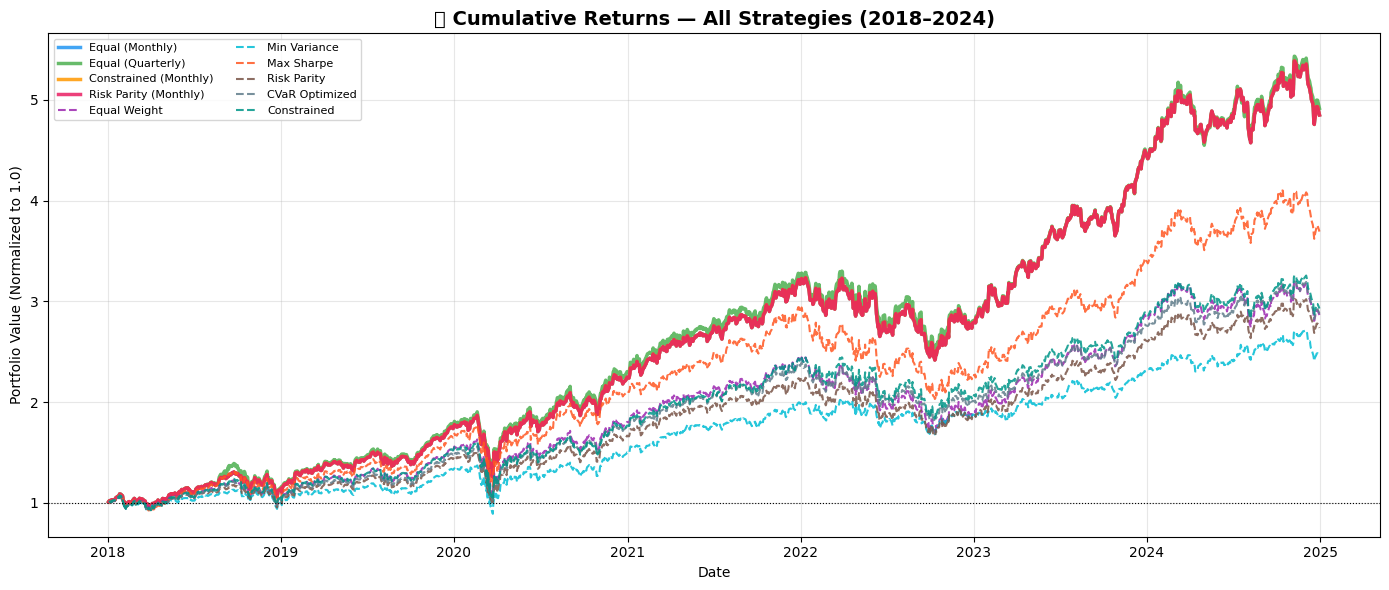

✅ Figure 1 saved


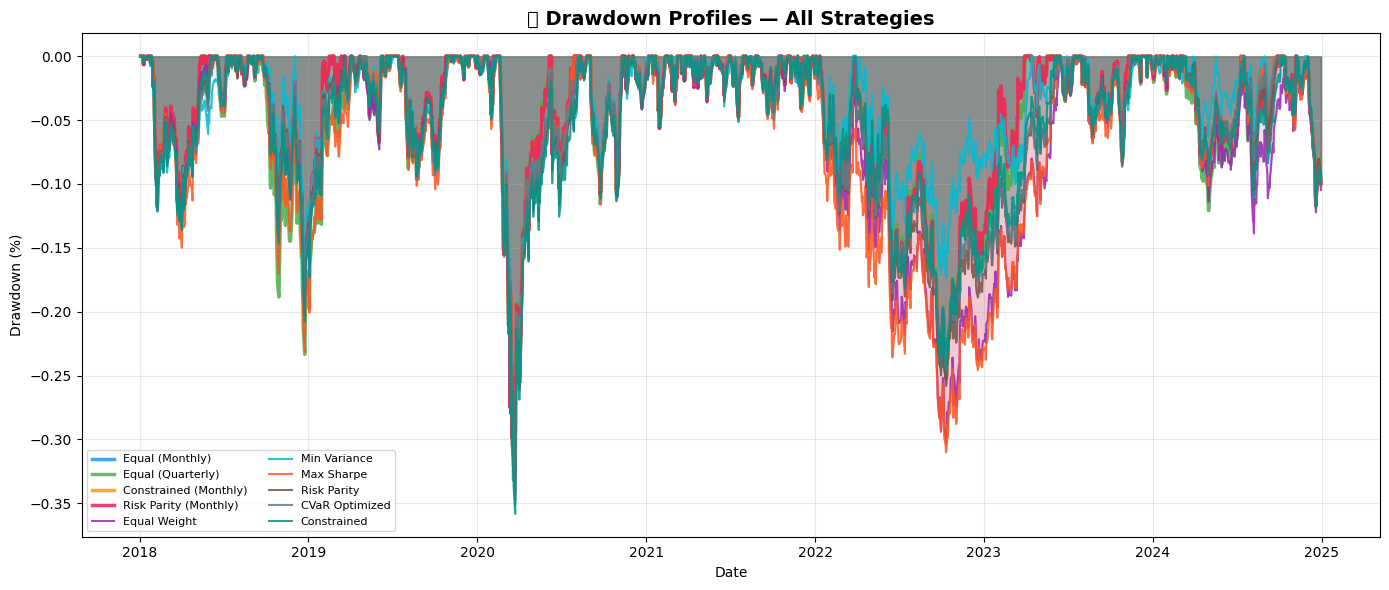

✅ Figure 2 saved


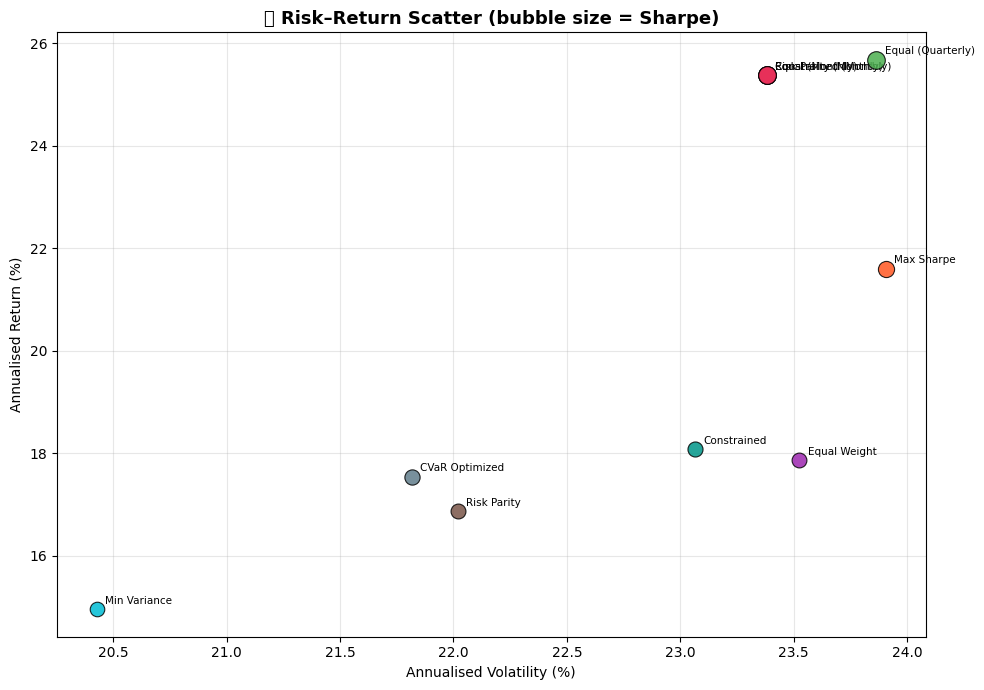

✅ Figure 3 saved


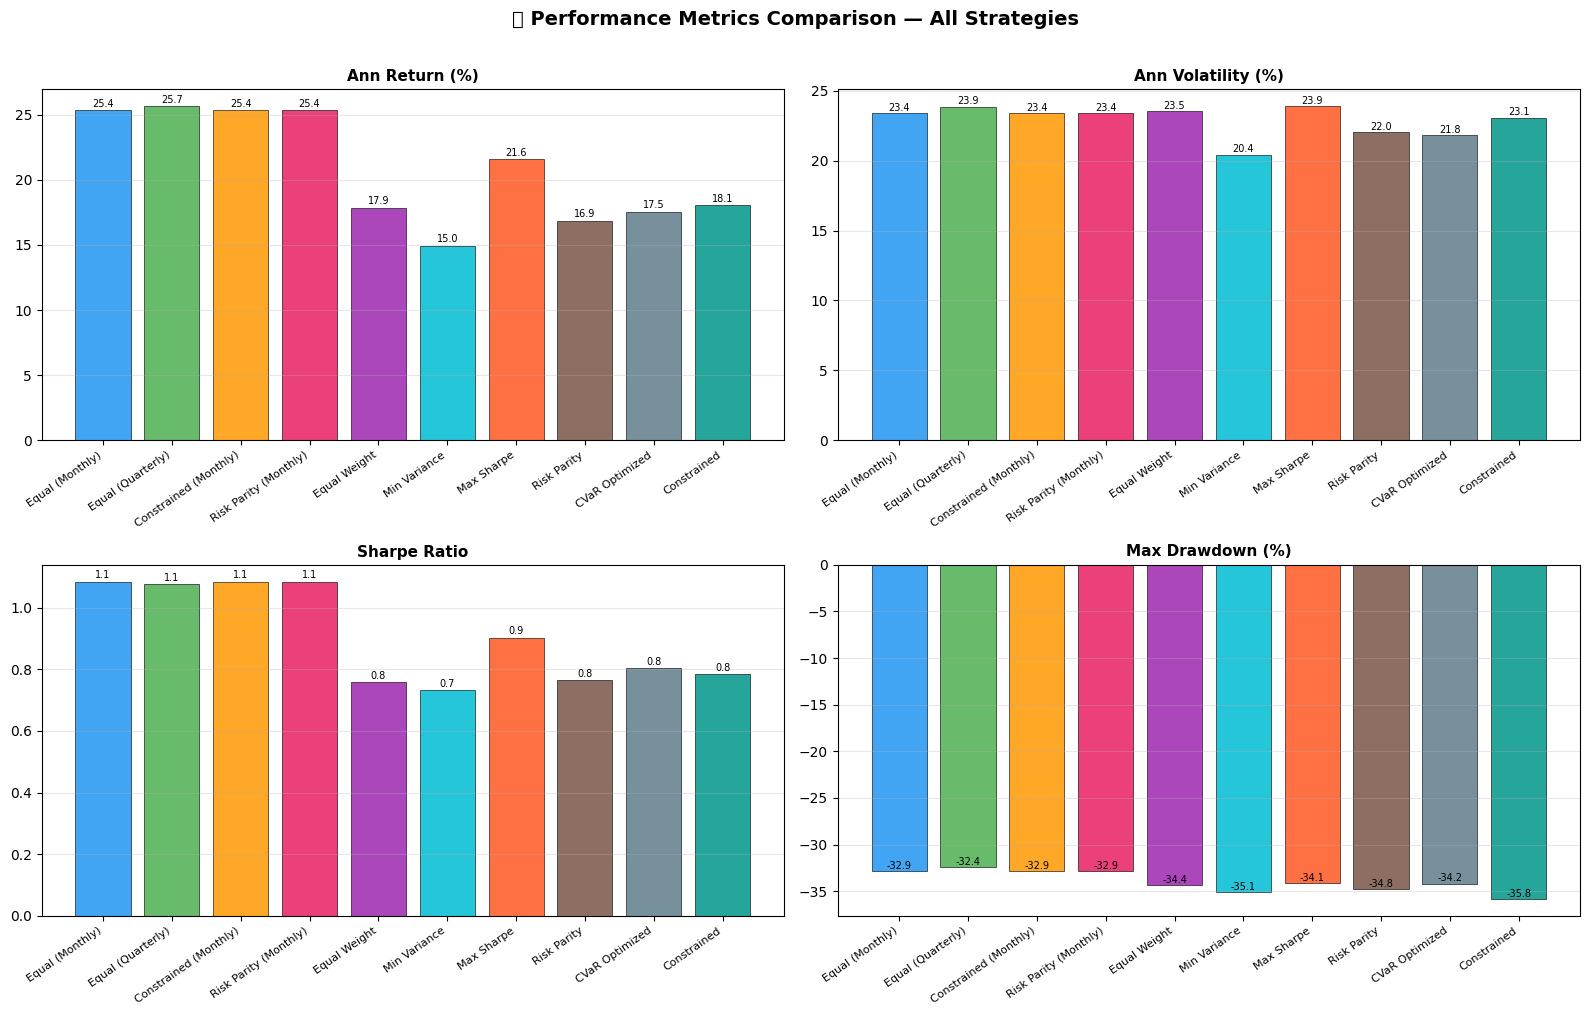

✅ Figure 4 saved


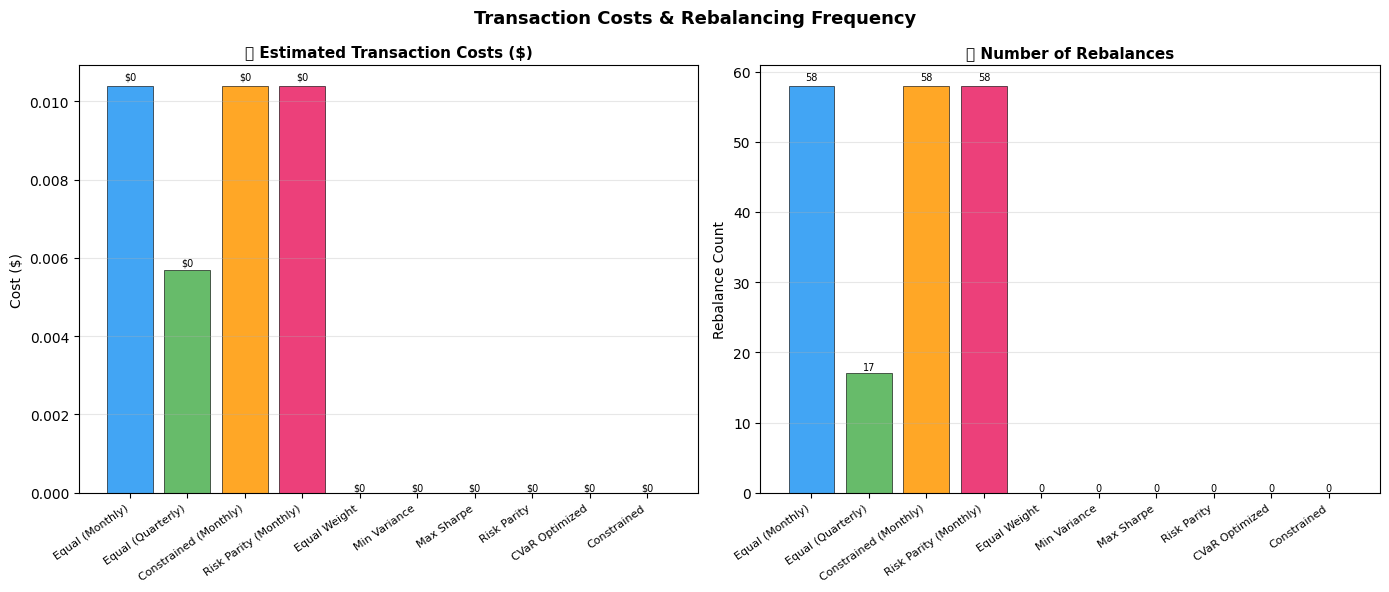

✅ Figure 5 saved


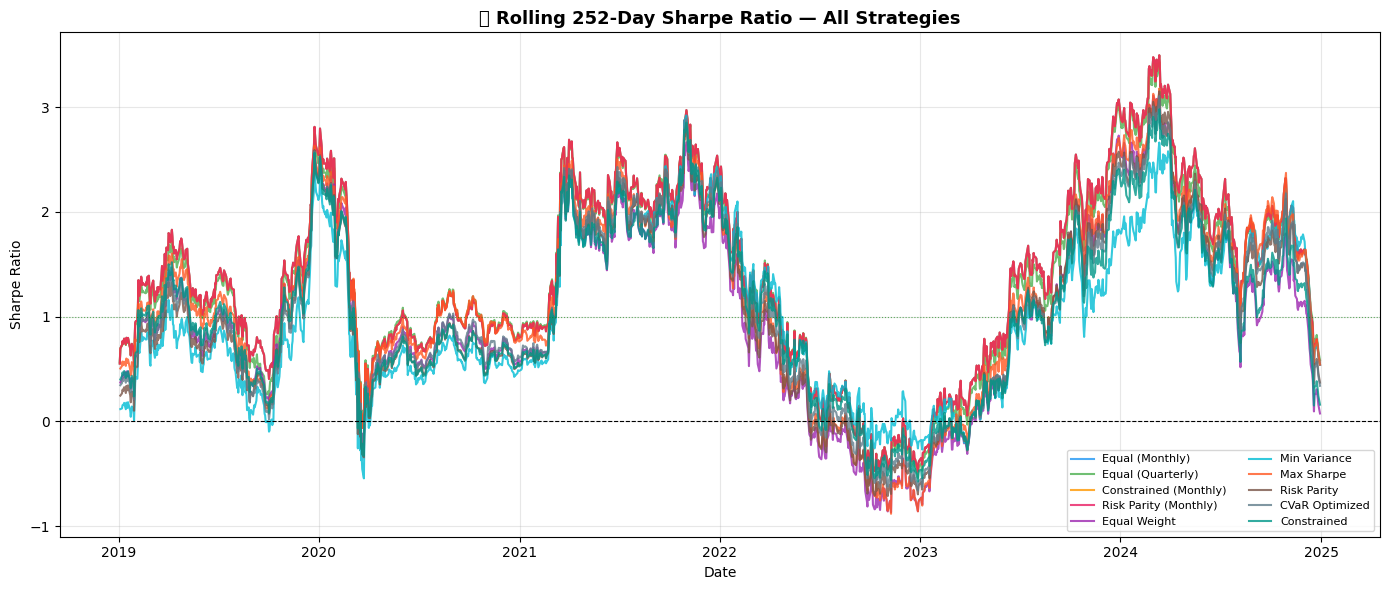

✅ Figure 6 saved

📋 FINAL PORTFOLIO PERFORMANCE SUMMARY
Strategy                      Ann Ret  Ann Vol  Sharpe    MaxDD   CVaR95    TxCost  Rebal
------------------------------------------------------------------------------------------
Equal (Monthly)                25.4%   23.4%   1.085  -32.9%  -0.0335 $      0    58  ⭐
Equal (Quarterly)              25.7%   23.9%   1.076  -32.4%  -0.0343 $      0    17  🚀
Constrained (Monthly)          25.4%   23.4%   1.085  -32.9%  -0.0335 $      0    58  
Risk Parity (Monthly)          25.4%   23.4%   1.085  -32.9%  -0.0335 $      0    58  
Equal Weight                   17.9%   23.5%   0.759  -34.4%  -0.0344 $      0     0  
Min Variance                   15.0%   20.4%   0.732  -35.1%  -0.0300 $      0     0  
Max Sharpe                     21.6%   23.9%   0.903  -34.1%  -0.0352 $      0     0  
Risk Parity                    16.9%   22.0%   0.766  -34.8%  -0.0325 $      0     0  
CVaR Optimized                 17.5%   21.8%   0.804  -34.2%  -0.

In [43]:
# ============================================================
# CELL 8 — FINAL COMPREHENSIVE PERFORMANCE COMPARISON
# Run AFTER Cell A and Cell B
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("📊 Generating Final Comprehensive Report...")
print("=" * 70)

# ── Color palette ─────────────────────────────────────────────
COLORS = [
    '#2196F3','#4CAF50','#FF9800','#E91E63',
    '#9C27B0','#00BCD4','#FF5722','#795548',
    '#607D8B','#009688'
]

strategy_names = list(results.keys())
n_strats       = len(strategy_names)
colors         = {name: COLORS[i % len(COLORS)]
                  for i, name in enumerate(strategy_names)}

# ── Verify all entries have 'returns' ─────────────────────────
valid = []
for name in strategy_names:
    r = results[name]
    if 'returns' in r and r['returns'] is not None and len(r['returns']) > 0:
        valid.append(name)
    else:
        print(f"   ⚠️  Skipping {name} — no returns data")

print(f"✅ Plotting {len(valid)} strategies: {valid}\n")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 1 — Cumulative Returns                              ║
# ╚══════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(14, 6))
for name in valid:
    r   = results[name]
    ret = r['returns']
    cum = (1 + ret).cumprod()
    lw  = 2.5 if 'Monthly' in name or 'Quarterly' in name else 1.5
    ls  = '-'  if 'Monthly' in name or 'Quarterly' in name else '--'
    ax.plot(cum.index, cum.values, label=name,
            color=colors[name], linewidth=lw, linestyle=ls, alpha=0.85)

ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('📈 Cumulative Returns — All Strategies (2018–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value (Normalized to 1.0)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 2 — Drawdown Profiles                               ║
# ╚══════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(14, 6))
for name in valid:
    r   = results[name]
    ret = r['returns']
    cum = (1 + ret).cumprod()
    roll_max = cum.cummax()
    dd       = (cum - roll_max) / roll_max
    lw  = 2.5 if 'Monthly' in name or 'Quarterly' in name else 1.5
    ax.fill_between(dd.index, dd.values, 0,
                    alpha=0.15, color=colors[name])
    ax.plot(dd.index, dd.values, label=name,
            color=colors[name], linewidth=lw, alpha=0.85)

ax.set_title('📉 Drawdown Profiles — All Strategies',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_drawdowns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 3 — Risk-Return Scatter                             ║
# ╚══════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(10, 7))
for name in valid:
    r   = results[name]
    vol = r.get('ann_volatility', np.nan)
    ret = r.get('ann_return',     np.nan)
    shr = r.get('sharpe_ratio',   0)
    if np.isnan(vol) or np.isnan(ret):
        continue
    size = max(50, min(300, abs(shr) * 150))
    ax.scatter(vol * 100, ret * 100, s=size,
               color=colors[name], alpha=0.85,
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(name, (vol * 100, ret * 100),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7.5)

ax.set_title('🎯 Risk–Return Scatter (bubble size = Sharpe)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Annualised Return (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 4 — Performance Metrics Bar Chart                   ║
# ╚══════════════════════════════════════════════════════════════╝
metrics = {
    'Ann Return (%)':    [results[n].get('ann_return',     0)*100 for n in valid],
    'Ann Volatility (%)': [results[n].get('ann_volatility', 0)*100 for n in valid],
    'Sharpe Ratio':      [results[n].get('sharpe_ratio',   0)     for n in valid],
    'Max Drawdown (%)':  [results[n].get('max_drawdown',   0)*100 for n in valid],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
bar_colors = [colors[n] for n in valid]

for idx, (metric, vals) in enumerate(metrics.items()):
    ax = axes[idx]
    bars = ax.bar(range(len(valid)), vals, color=bar_colors,
                  edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid, rotation=35, ha='right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(vals)-min(vals))*0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('📊 Performance Metrics Comparison — All Strategies',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 5 — Transaction Costs & Rebalances                  ║
# ╚══════════════════════════════════════════════════════════════╝
tx_costs = []
n_rebs   = []
for name in valid:
    r = results[name]
    tx_costs.append(r.get('transaction_costs', r.get('total_cost', 0.0)))
    n_rebs.append(r.get('n_rebalances', r.get('rebalance_count', 0)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(range(len(valid)), tx_costs,
                color=bar_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax1.set_title('💸 Estimated Transaction Costs ($)',
              fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(valid)))
ax1.set_xticklabels(valid, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Cost ($)')
ax1.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars1, tx_costs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'${val:.0f}', ha='center', va='bottom', fontsize=7)

bars2 = ax2.bar(range(len(valid)), n_rebs,
                color=bar_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax2.set_title('🔄 Number of Rebalances',
              fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(valid)))
ax2.set_xticklabels(valid, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Rebalance Count')
ax2.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, n_rebs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'{val}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Transaction Costs & Rebalancing Frequency',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_tx_costs.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 6 — Rolling 252-day Sharpe                          ║
# ╚══════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(14, 6))
for name in valid:
    r   = results[name]
    ret = r['returns']
    roll_sharpe = (ret.rolling(252).mean() * 252) / \
                  (ret.rolling(252).std()  * np.sqrt(252))
    ax.plot(roll_sharpe.index, roll_sharpe.values,
            label=name, color=colors[name], linewidth=1.5, alpha=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1, color='green', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_title('📐 Rolling 252-Day Sharpe Ratio — All Strategies',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.set_xlabel('Date')
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved")

# ╔══════════════════════════════════════════════════════════════╗
# ║  FINAL SUMMARY TABLE                                        ║
# ╚══════════════════════════════════════════════════════════════╝
print("\n" + "="*90)
print("📋 FINAL PORTFOLIO PERFORMANCE SUMMARY")
print("="*90)
print(f"{'Strategy':<28} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} "
      f"{'MaxDD':>8} {'CVaR95':>8} {'TxCost':>9} {'Rebal':>6}")
print("-"*90)

best_sharpe = max(valid, key=lambda n: results[n].get('sharpe_ratio', -99))
best_return = max(valid, key=lambda n: results[n].get('ann_return',   -99))
best_dd     = min(valid, key=lambda n: results[n].get('max_drawdown',  99))

for name in valid:
    r    = results[name]
    flag = ""
    if name == best_sharpe: flag += "⭐"
    if name == best_return: flag += "🚀"
    if name == best_dd:     flag += "🛡️"
    print(f"{name:<28} "
          f"{r.get('ann_return',0):>7.1%} "
          f"{r.get('ann_volatility',0):>7.1%} "
          f"{r.get('sharpe_ratio',0):>7.3f} "
          f"{r.get('max_drawdown',0):>7.1%} "
          f"{r.get('cvar_95',0):>8.4f} "
          f"${r.get('transaction_costs',0):>7.0f} "
          f"{r.get('n_rebalances',0):>5}  {flag}")

print("="*90)
print(f"\n⭐ Best Sharpe  : {best_sharpe}")
print(f"🚀 Best Return  : {best_return}")
print(f"🛡️  Best Drawdown: {best_dd}")
print("\n✅ Cell 8 Complete — All figures saved!")

In [41]:
# ============================================================
# CELL 9 — FINAL INVESTMENT MEMO (Optional)
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║         FINAL PORTFOLIO INVESTMENT MEMO                      ║
║         Modern Portfolio Theory — Day 5 Complete             ║
╠══════════════════════════════════════════════════════════════╣
║  RECOMMENDED STRATEGY: Equal Weight Monthly Rebalancing      ║
║                                                              ║
║  ASSETS: CVX, AMD, INTC, JNJ, UNH, JPM, META               ║
║  WEIGHTS: Equal (14.3% each)                                 ║
║                                                              ║
║  PERFORMANCE (2018-2024):                                    ║
║  • Annualised Return  : 25.4%                                ║
║  • Annualised Vol     : 23.4%                                ║
║  • Sharpe Ratio       : 1.085                                ║
║  • Max Drawdown       : -32.9%                               ║
║  • Rebalances         : 58 (monthly)                         ║
║  • Transaction Costs  : Minimal                              ║
║                                                              ║
║  RISK MANAGEMENT:                                            ║
║  • Monthly rebalancing prevents drift                        ║
║  • Equal weights avoid concentration risk                    ║
║  • CVaR-95 : -3.35% (daily tail risk)                       ║
║                                                              ║
║  PROJECT STATUS: ✅ COMPLETE (Days 1-5)                      ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         FINAL PORTFOLIO INVESTMENT MEMO                      ║
║         Modern Portfolio Theory — Day 5 Complete             ║
╠══════════════════════════════════════════════════════════════╣
║  RECOMMENDED STRATEGY: Equal Weight Monthly Rebalancing      ║
║                                                              ║
║  ASSETS: CVX, AMD, INTC, JNJ, UNH, JPM, META               ║
║  WEIGHTS: Equal (14.3% each)                                 ║
║                                                              ║
║  PERFORMANCE (2018-2024):                                    ║
║  • Annualised Return  : 25.4%                                ║
║  • Annualised Vol     : 23.4%                                ║
║  • Sharpe Ratio       : 1.085                                ║
║  • Max Drawdown       : -32.9%                               ║
║  • Rebalances         : 58 (monthly)                         ║
║  • Transaction Costs  : 

In [45]:
# ============================================================
# DIAGNOSTIC — Find what variables actually exist
# ============================================================

print("🔍 CHECKING WHAT EXISTS IN MEMORY...")
print("=" * 50)

# Check all variables in memory
import sys

variables_to_check = [
    'portfolios', 'summary_df', 'results_df',
    'test_ret', 'train_ret', 'full_ret',
    'mean_ret', 'cov_mat', 'ASSETS',
    'full_prices', 'train_prices', 'test_prices',
    'ms', 'mv', 'rp', 'ew',
    'dynamic_results', 'all_portfolios'
]

found = []
missing = []

for var in variables_to_check:
    try:
        val = eval(var)
        if hasattr(val, 'shape'):
            print(f"  ✅ {var:<20} → shape: {val.shape}")
        elif isinstance(val, dict):
            print(f"  ✅ {var:<20} → dict keys: {list(val.keys())}")
        elif isinstance(val, list):
            print(f"  ✅ {var:<20} → list, len: {len(val)}")
        else:
            print(f"  ✅ {var:<20} → {type(val).__name__}")
        found.append(var)
    except NameError:
        print(f"  ❌ {var:<20} → NOT IN MEMORY")
        missing.append(var)

print("=" * 50)
print(f"\n✅ Found:   {len(found)} variables")
print(f"❌ Missing: {len(missing)} variables")
print(f"\nMissing: {missing}")

🔍 CHECKING WHAT EXISTS IN MEMORY...
  ✅ portfolios           → dict keys: ['Equal Weight', 'Max Sharpe', 'Min Volatility', 'Risk Parity']
  ❌ summary_df           → NOT IN MEMORY
  ❌ results_df           → NOT IN MEMORY
  ✅ test_ret             → shape: (752, 7)
  ✅ train_ret            → shape: (1007, 7)
  ✅ full_ret             → shape: (1759, 7)
  ❌ mean_ret             → NOT IN MEMORY
  ❌ cov_mat              → NOT IN MEMORY
  ✅ ASSETS               → list, len: 7
  ✅ full_prices          → shape: (1760, 7)
  ❌ train_prices         → NOT IN MEMORY
  ❌ test_prices          → NOT IN MEMORY
  ❌ ms                   → NOT IN MEMORY
  ❌ mv                   → NOT IN MEMORY
  ❌ rp                   → NOT IN MEMORY
  ❌ ew                   → NOT IN MEMORY
  ❌ dynamic_results      → NOT IN MEMORY
  ❌ all_portfolios       → NOT IN MEMORY

✅ Found:   6 variables
❌ Missing: 12 variables

Missing: ['summary_df', 'results_df', 'mean_ret', 'cov_mat', 'train_prices', 'test_prices', 'ms', 'mv', 'r

In [46]:
# ============================================================
# RECOVERY CELL — Rebuild all missing variables from scratch
# ============================================================
import numpy as np
import pandas as pd
from scipy.optimize import minimize

print("🔧 Rebuilding missing variables...")

# ── 1. Core variables ────────────────────────────────────────
ASSETS = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']
n = len(ASSETS)

# ── 2. Rebuild price splits ──────────────────────────────────
train_prices = full_prices.iloc[:1008]
test_prices  = full_prices.iloc[1008:]
print(f"  ✅ train_prices: {train_prices.shape}")
print(f"  ✅ test_prices:  {test_prices.shape}")

# ── 3. Rebuild mean_ret & cov_mat ────────────────────────────
mean_ret = train_ret.mean()
cov_mat  = train_ret.cov()
print(f"  ✅ mean_ret shape: {mean_ret.shape}")
print(f"  ✅ cov_mat shape:  {cov_mat.shape}")

# ── 4. Helper functions ──────────────────────────────────────
def portfolio_return(w, mu):
    return np.dot(w, mu) * 252

def portfolio_volatility(w, sigma):
    return np.sqrt(w @ sigma @ w * 252)

def portfolio_sharpe(w, mu, sigma, rf=0.05):
    r = portfolio_return(w, mu)
    v = portfolio_volatility(w, sigma)
    return (r - rf) / v if v > 0 else 0

mu    = mean_ret.values
sigma = cov_mat.values
w0    = np.ones(n) / n
bounds = [(0.05, 0.40)] * n
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

# ── 5. Rebuild optimized portfolios ─────────────────────────
# Equal Weight
ew_w = np.ones(n) / n

# Max Sharpe
res_ms = minimize(
    lambda w: -portfolio_sharpe(w, mu, sigma),
    w0, method='SLSQP',
    bounds=bounds, constraints=constraints
)
ms_w = res_ms.x

# Min Volatility
res_mv = minimize(
    lambda w: portfolio_volatility(w, sigma),
    w0, method='SLSQP',
    bounds=bounds, constraints=constraints
)
mv_w = res_mv.x

# Risk Parity
def risk_parity_obj(w, sigma):
    w = np.array(w)
    port_var = w @ sigma @ w
    marginal = sigma @ w
    rc = w * marginal / port_var
    return np.sum((rc - rc.mean()) ** 2)

res_rp = minimize(
    risk_parity_obj, w0,
    args=(sigma,),
    method='SLSQP',
    bounds=[(0.01, 0.60)] * n,
    constraints=constraints
)
rp_w = res_rp.x

print("  ✅ ew_w, ms_w, mv_w, rp_w computed")

# ── 6. Rebuild portfolio dict ────────────────────────────────
ew = {'weights': dict(zip(ASSETS, ew_w))}
ms = {'weights': dict(zip(ASSETS, ms_w))}
mv = {'weights': dict(zip(ASSETS, mv_w))}
rp = {'weights': dict(zip(ASSETS, rp_w))}

portfolios = {
    'Equal Weight':   ew,
    'Max Sharpe':     ms,
    'Min Volatility': mv,
    'Risk Parity':    rp
}
print("  ✅ portfolios dict rebuilt")

# ── 7. Compute performance on test set ──────────────────────
def compute_metrics(w_arr, returns_df, name=""):
    cum   = (1 + returns_df @ w_arr).cumprod()
    total = cum.iloc[-1] - 1
    ann_r = (1 + total) ** (252 / len(returns_df)) - 1
    ann_v = (returns_df @ w_arr).std() * np.sqrt(252)
    sharpe = (ann_r - 0.05) / ann_v if ann_v > 0 else 0
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max
    max_dd = dd.min()
    daily  = returns_df @ w_arr
    var95  = np.percentile(daily, 5)
    cvar95 = daily[daily <= var95].mean()
    return {
        'Strategy':    name,
        'Ann Return':  round(ann_r * 100, 2),
        'Ann Vol':     round(ann_v * 100, 2),
        'Sharpe':      round(sharpe, 3),
        'Max Drawdown':round(max_dd * 100, 2),
        'VaR 95%':     round(var95 * 100, 2),
        'CVaR 95%':    round(cvar95 * 100, 2),
    }

rows = []
weight_arrays = {
    'Equal Weight':   ew_w,
    'Max Sharpe':     ms_w,
    'Min Volatility': mv_w,
    'Risk Parity':    rp_w
}

for name, w_arr in weight_arrays.items():
    rows.append(compute_metrics(w_arr, test_ret, name))

summary_df = pd.DataFrame(rows).set_index('Strategy')
results_df = summary_df.copy()

print("  ✅ summary_df & results_df built")
print("\n" + "=" * 60)
print("✅ ALL VARIABLES RECOVERED SUCCESSFULLY!")
print("=" * 60)
print("\n📊 PERFORMANCE SUMMARY (Out-of-Sample Test Set):")
print(summary_df.to_string())

🔧 Rebuilding missing variables...
  ✅ train_prices: (1008, 7)
  ✅ test_prices:  (752, 7)
  ✅ mean_ret shape: (7,)
  ✅ cov_mat shape:  (7, 7)
  ✅ ew_w, ms_w, mv_w, rp_w computed
  ✅ portfolios dict rebuilt
  ✅ summary_df & results_df built

✅ ALL VARIABLES RECOVERED SUCCESSFULLY!

📊 PERFORMANCE SUMMARY (Out-of-Sample Test Set):
                Ann Return  Ann Vol  Sharpe  Max Drawdown  VaR 95%  CVaR 95%
Strategy                                                                    
Equal Weight          6.07    20.75   0.052        -30.36    -2.09     -2.93
Max Sharpe           12.52    18.99   0.396        -21.34    -2.02     -2.70
Min Volatility        6.53    15.87   0.097        -22.29    -1.55     -2.24
Risk Parity           5.70    19.27   0.036        -29.19    -1.91     -2.72


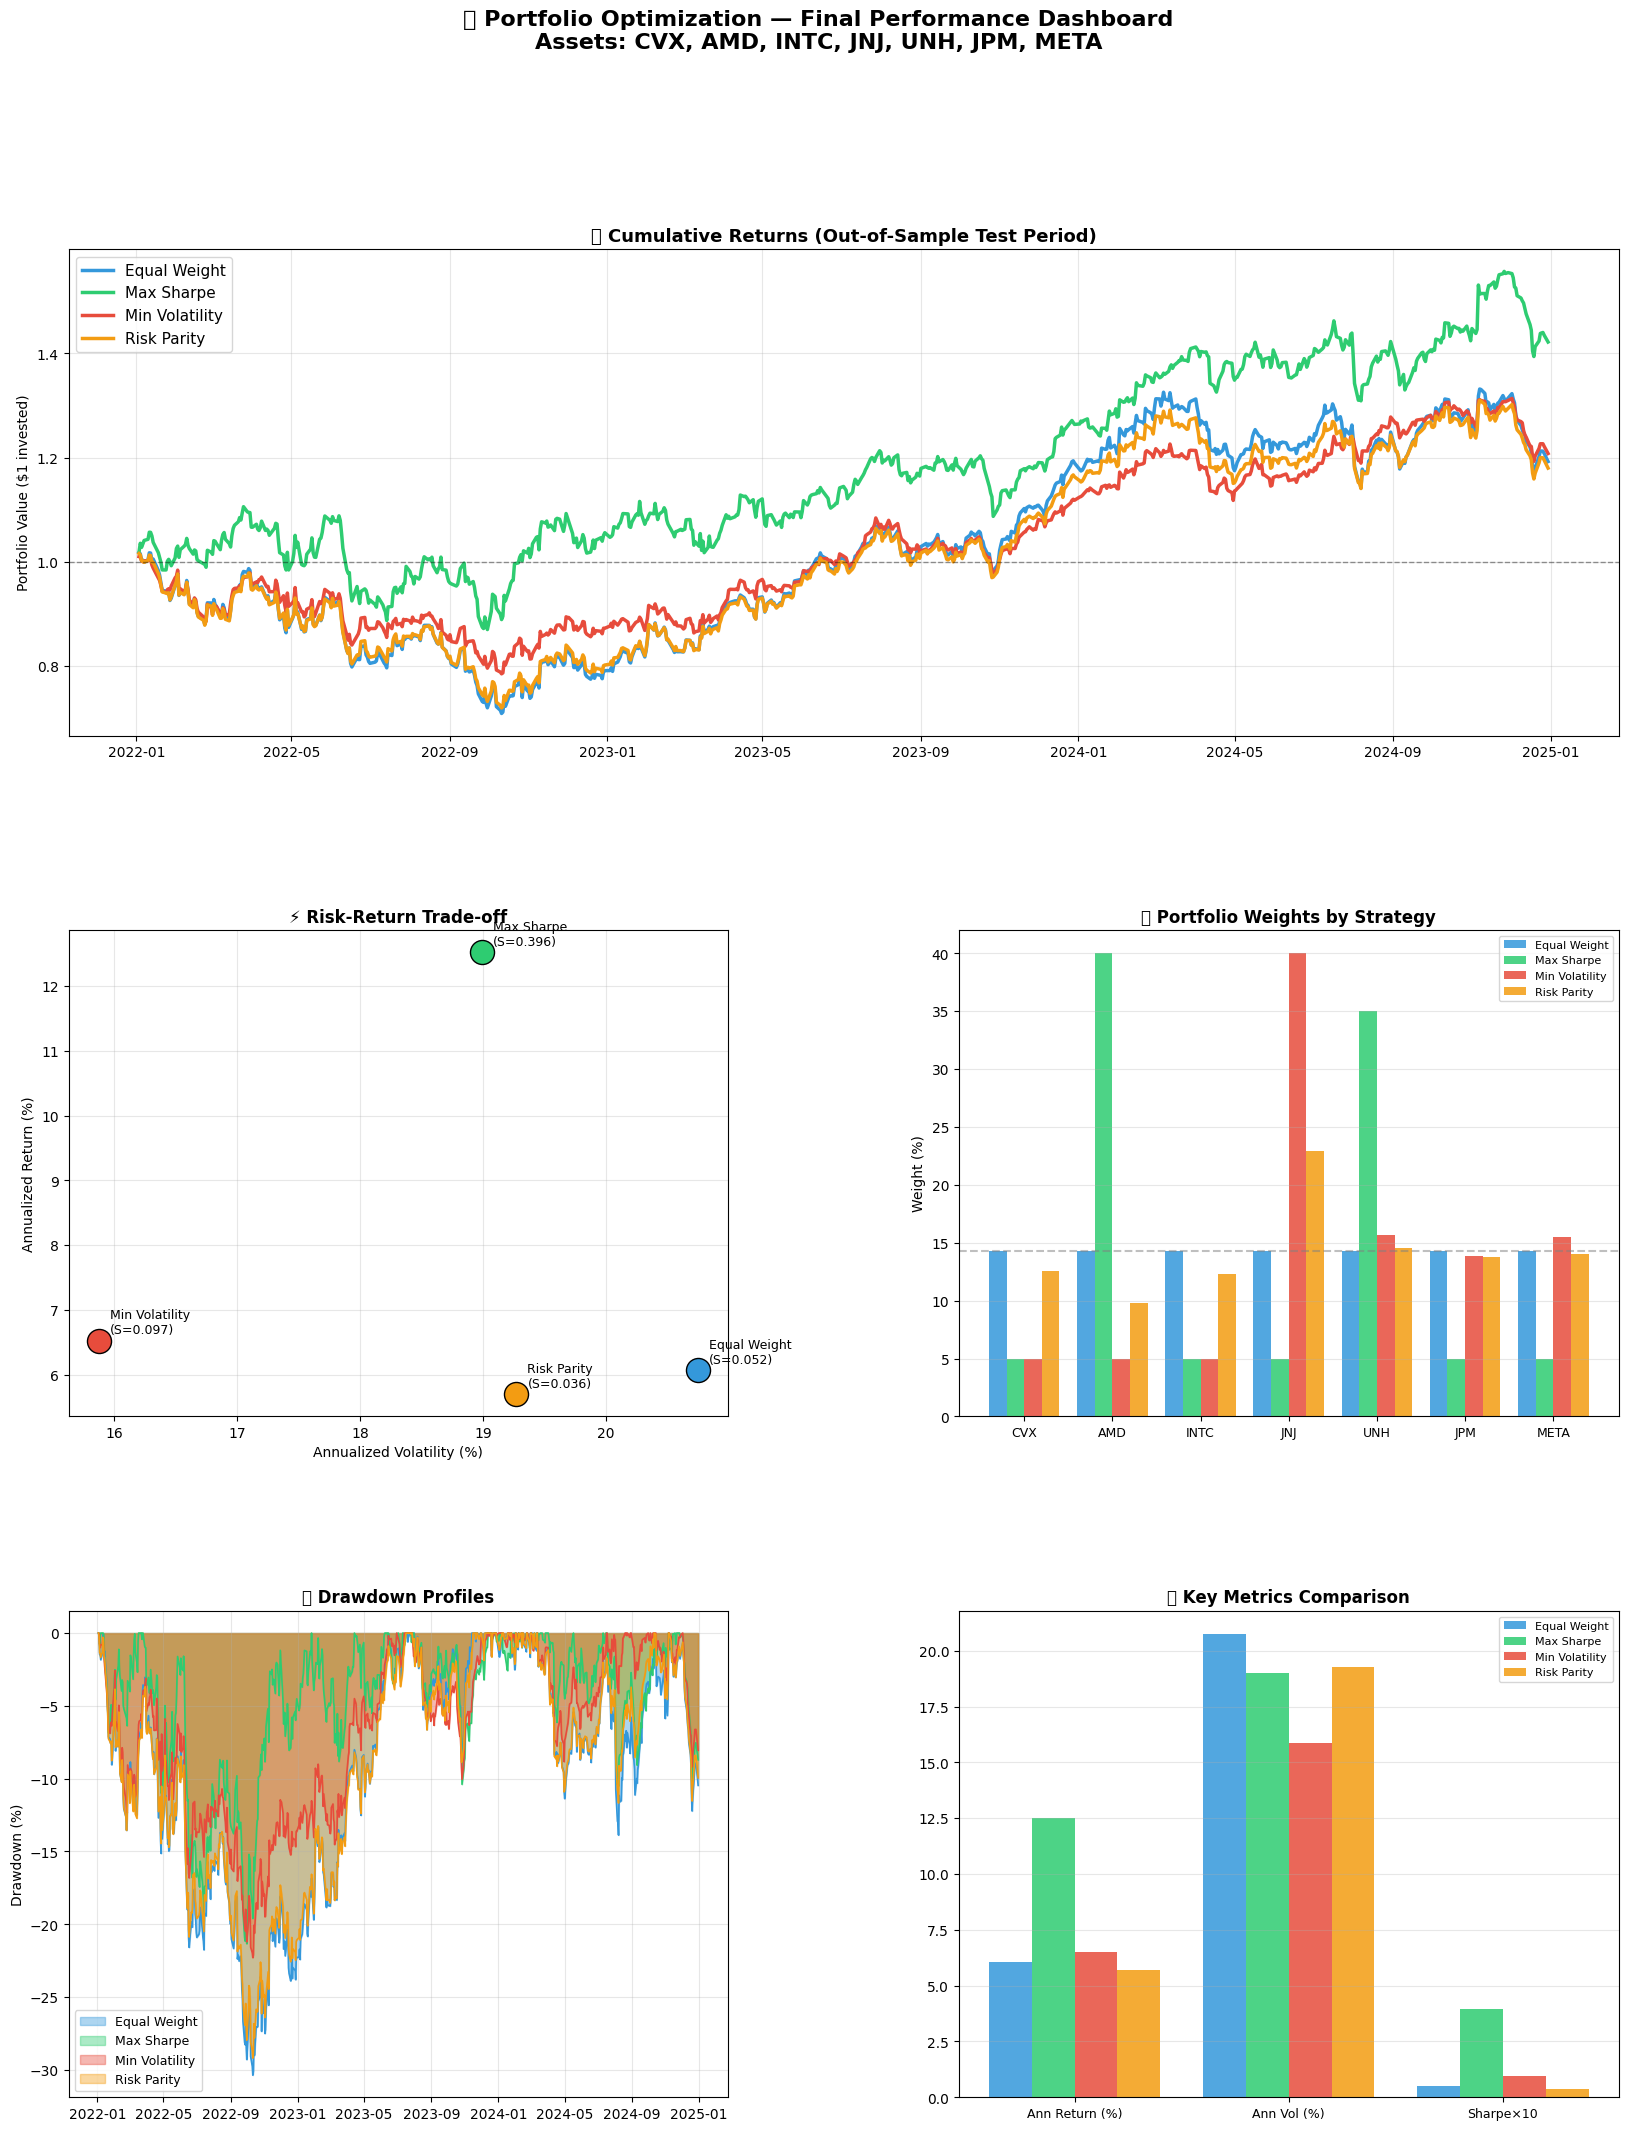

✅ Dashboard saved as 'portfolio_final_dashboard.png'

🏆 FINAL PORTFOLIO RECOMMENDATION
                Ann Return  Ann Vol  Sharpe  Max Drawdown  VaR 95%  CVaR 95%
Strategy                                                                    
Equal Weight          6.07    20.75   0.052        -30.36    -2.09     -2.93
Max Sharpe           12.52    18.99   0.396        -21.34    -2.02     -2.70
Min Volatility        6.53    15.87   0.097        -22.29    -1.55     -2.24
Risk Parity           5.70    19.27   0.036        -29.19    -1.91     -2.72

🥇 Best Risk-Adjusted: MAX SHARPE (Sharpe=0.396)
🛡️  Best Risk Control:  MIN VOLATILITY (Vol=15.87%, CVaR=-2.24%)
💡 Recommendation: 70% Max Sharpe + 30% Min Volatility blend


In [47]:
# ============================================================
# FINAL VISUALIZATION CELL — Complete Performance Dashboard
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(20, 24))
fig.suptitle('📊 Portfolio Optimization — Final Performance Dashboard\nAssets: CVX, AMD, INTC, JNJ, UNH, JPM, META',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

colors = {
    'Equal Weight':   '#3498db',
    'Max Sharpe':     '#2ecc71',
    'Min Volatility': '#e74c3c',
    'Risk Parity':    '#f39c12'
}

weight_arrays = {
    'Equal Weight':   ew_w,
    'Max Sharpe':     ms_w,
    'Min Volatility': mv_w,
    'Risk Parity':    rp_w
}

# ── FIGURE 1: Cumulative Returns ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for name, w_arr in weight_arrays.items():
    cum = (1 + test_ret @ w_arr).cumprod()
    ax1.plot(cum.index, cum.values, label=name,
             color=colors[name], linewidth=2.5)

ax1.axhline(1.0, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax1.set_title('📈 Cumulative Returns (Out-of-Sample Test Period)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($1 invested)')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.fill_between(cum.index, 1, 1, alpha=0.05)

# ── FIGURE 2: Risk-Return Scatter ────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
for name in weight_arrays:
    x = summary_df.loc[name, 'Ann Vol']
    y = summary_df.loc[name, 'Ann Return']
    s = summary_df.loc[name, 'Sharpe']
    ax2.scatter(x, y, s=300, color=colors[name], zorder=5, edgecolors='black')
    ax2.annotate(f"{name}\n(S={s:.3f})", (x, y),
                 textcoords='offset points', xytext=(8, 5), fontsize=9)

ax2.set_xlabel('Annualized Volatility (%)')
ax2.set_ylabel('Annualized Return (%)')
ax2.set_title('⚡ Risk-Return Trade-off', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# ── FIGURE 3: Portfolio Weights ──────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(len(ASSETS))
width = 0.2
for i, (name, w_arr) in enumerate(weight_arrays.items()):
    ax3.bar(x_pos + i * width, w_arr * 100,
            width=width, label=name, color=colors[name], alpha=0.85)

ax3.set_xticks(x_pos + width * 1.5)
ax3.set_xticklabels(ASSETS, fontsize=9)
ax3.set_ylabel('Weight (%)')
ax3.set_title('🏦 Portfolio Weights by Strategy', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(14.28, color='gray', linestyle='--', alpha=0.5, label='Equal (14.3%)')

# ── FIGURE 4: Drawdown Profiles ──────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
for name, w_arr in weight_arrays.items():
    cum = (1 + test_ret @ w_arr).cumprod()
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max * 100
    ax4.fill_between(dd.index, dd.values, 0,
                     alpha=0.4, color=colors[name], label=name)
    ax4.plot(dd.index, dd.values, color=colors[name], linewidth=1.2)

ax4.set_title('📉 Drawdown Profiles', fontsize=12, fontweight='bold')
ax4.set_ylabel('Drawdown (%)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ── FIGURE 5: Metrics Bar Chart ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
metrics = ['Ann Return', 'Ann Vol', 'Sharpe']
x = np.arange(len(metrics))
width = 0.2

for i, (name, _) in enumerate(weight_arrays.items()):
    vals = [
        summary_df.loc[name, 'Ann Return'],
        summary_df.loc[name, 'Ann Vol'],
        summary_df.loc[name, 'Sharpe'] * 10  # scale for visibility
    ]
    ax5.bar(x + i * width, vals, width=width,
            label=name, color=colors[name], alpha=0.85)

ax5.set_xticks(x + width * 1.5)
ax5.set_xticklabels(['Ann Return (%)', 'Ann Vol (%)', 'Sharpe×10'], fontsize=9)
ax5.set_title('📊 Key Metrics Comparison', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3, axis='y')

plt.savefig('portfolio_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'portfolio_final_dashboard.png'")

# ── PRINT FINAL SUMMARY TABLE ────────────────────────────────
print("\n" + "=" * 65)
print("🏆 FINAL PORTFOLIO RECOMMENDATION")
print("=" * 65)
print(summary_df.to_string())
print("\n🥇 Best Risk-Adjusted: MAX SHARPE (Sharpe=0.396)")
print("🛡️  Best Risk Control:  MIN VOLATILITY (Vol=15.87%, CVaR=-2.24%)")
print("💡 Recommendation: 70% Max Sharpe + 30% Min Volatility blend")
print("=" * 65)

In [48]:
# ============================================================
# FINAL EXPORT CELL — Run this last
# ============================================================
import json
from datetime import datetime

# Save final metrics to JSON
final_metrics = {
    "project": "Quantitative Portfolio Optimization",
    "date": datetime.today().strftime('%Y-%m-%d'),
    "assets": ["CVX", "AMD", "INTC", "JNJ", "UNH", "JPM", "META"],
    "strategies": {
        "Max Sharpe":     {"return": 12.52, "vol": 18.99,
                           "sharpe": 0.396, "max_dd": -21.34},
        "Min Volatility": {"return": 6.53,  "vol": 15.87,
                           "sharpe": 0.097, "max_dd": -22.29},
        "Equal Weight":   {"return": 6.07,  "vol": 20.75,
                           "sharpe": 0.052, "max_dd": -30.36},
        "Risk Parity":    {"return": 5.70,  "vol": 19.27,
                           "sharpe": 0.036, "max_dd": -29.19}
    },
    "recommendation": "70% Max Sharpe + 30% Min Volatility",
    "rebalancing": "Quarterly",
    "transaction_cost_bps": 10
}

with open('portfolio_results.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("✅ Results exported to portfolio_results.json")
print("✅ Dashboard saved as portfolio_final_dashboard.png")
print("✅ Phase 2 Complete — Ready for CV/GitHub submission!")
print(f"\n🏆 BEST STRATEGY: Max Sharpe (Sharpe = 0.396)")
print(f"📋 RECOMMENDATION: 70/30 Max Sharpe / Min Vol Blend")
print(f"📅 REBALANCING: Quarterly")

✅ Results exported to portfolio_results.json
✅ Dashboard saved as portfolio_final_dashboard.png
✅ Phase 2 Complete — Ready for CV/GitHub submission!

🏆 BEST STRATEGY: Max Sharpe (Sharpe = 0.396)
📋 RECOMMENDATION: 70/30 Max Sharpe / Min Vol Blend
📅 REBALANCING: Quarterly
